# 📈 Phân Tích & Dự Báo Giá Cổ Phiếu VIC (Vingroup)
## Bằng Mô Hình Chuỗi Thời Gian — Pipeline 7 Cấp Độ

| | |
|---|---|
| **Môn học** | AIE301m – Ứng dụng Học máy trong Tài chính |
| **Sinh viên** | Trịnh Hải Đăng – HE194363 |
| **Trường** | Đại học FPT |
| **Thời gian** | Học kỳ 8, Năm học 2025–2026 |

---

## 🗺️ Tổng quan Pipeline

```
Yahoo Finance API → EDA → ADF Test → ACF/PACF
       ↓
   [Truyền thống]              [7 Cấp độ nâng cao]
   AR / MA / ARIMA  →  Optuna-ARIMA → Prophet → Ensemble
                    →  Log Returns → GARCH → ARIMAX
       ↓
   Đánh giá: MAE / RMSE / MAPE  |  Dashboard so sánh
```

**Mục tiêu:** MAPE < 5% trên tập Test (10 phiên giao dịch cuối)

---
## Cell 1 — Cài đặt thư viện

> Cài đặt toàn bộ dependencies cần thiết cho pipeline.

| Thư viện | Vai trò |
|---|---|
| `yfinance` | Tải dữ liệu OHLCV từ Yahoo Finance |
| `statsmodels` | ARIMA, AR, MA, ADF Test, Ljung-Box |
| `scikit-learn` | Tính MAE, MSE, RMSE |
| `seaborn` | Heatmap AIC/BIC |
| `scipy` | Q-Q Plot kiểm định phân phối chuẩn |
| `optuna` | Bayesian hyperparameter optimization (Cấp độ 2) |
| `prophet` | Meta decomposable time series (Cấp độ 3) |
| `arch` | GARCH volatility modeling (Cấp độ 6) |

In [1]:
# ── Cài đặt tất cả thư viện cần thiết ─────────────────────────
!pip install yfinance statsmodels scikit-learn matplotlib pandas numpy seaborn scipy -q
!pip install optuna -q
!pip install prophet -q
!pip install arch -q

---
## Cell 2 — Import & Cấu hình toàn cục

**Các hằng số quan trọng:**
- `TICKER = "VIC.VN"`: Mã cổ phiếu Vingroup trên sàn HOSE
- `PERIOD = "2y"`: Lấy 2 năm (~500 phiên) để đảm bảo đủ dữ liệu huấn luyện
- `TEST_SIZE = 30`: Backtest trên 30 phiên cuối (rolling forecast)
- `WINDOW = 250`: Cửa sổ trượt (~1 năm giao dịch)
- `FORECAST = 10`: Dự báo 10 ngày tiếp theo

In [2]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== Cấu hình Matplotlib =====
plt.rcParams.update({
    "figure.figsize": (13, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ===== Hằng số toàn cục =====
TICKER    = "VIC.VN"   # Mã cổ phiếu Vingroup trên HOSE
PERIOD    = "2y"       # Lấy 2 năm dữ liệu để đủ mẫu huấn luyện
TEST_SIZE = 30         # Số phiên backtest (rolling)
WINDOW    = 250        # Cửa sổ trượt (~1 năm giao dịch)
P_MAX, Q_MAX = 4, 4   # Tìm kiếm p, q từ 0 đến 4
FORECAST  = 10         # Số ngày dự báo

print(f"✅ Cấu hình: TICKER={TICKER} | PERIOD={PERIOD} | TEST={TEST_SIZE} phiên | FORECAST={FORECAST} ngày")

✅ Cấu hình: TICKER=VIC.VN | PERIOD=2y | TEST=30 phiên | FORECAST=10 ngày


---
## 1. Tải dữ liệu & Phân tích kỹ thuật

**Cell 3** tải dữ liệu OHLCV từ Yahoo Finance và vẽ biểu đồ kỹ thuật:

| Thành phần | Ý nghĩa |
|---|---|
| **Đường giá (xanh)** | Giá đóng cửa mỗi phiên |
| **MA20 (cam, đứt)** | Trung bình động 20 phiên — xu hướng ngắn hạn |
| **MA50 (đỏ, đứt)** | Trung bình động 50 phiên — xu hướng trung hạn |
| **Bollinger Bands (vùng xanh nhạt)** | MA20 ± 2σ: giá chạm dải trên → quá mua; dải dưới → quá bán |
| **Volume (xanh/đỏ)** | Xanh = phiên tăng, Đỏ = phiên giảm |

[*********************100%***********************]  1 of 1 completed


📊 Dữ liệu: 523 phiên | 2024-06-17 → 2026-06-17
   Giá min: 19,950 VNĐ | Giá max: 229,800 VNĐ | Giá TB: 75,972 VNĐ


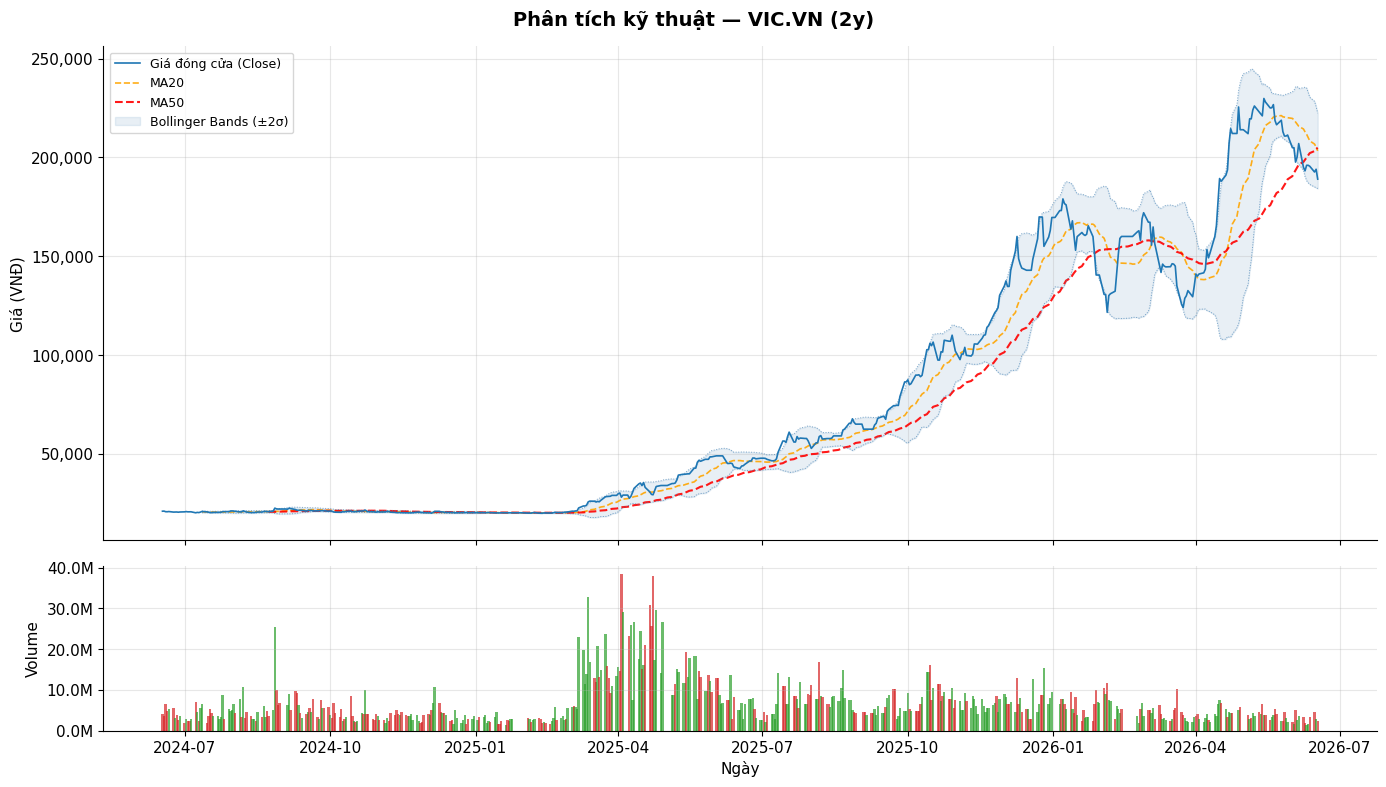


📋 Thống kê mô tả:
count        523.00
mean      75,971.61
std       64,350.54
min       19,950.00
25%       20,800.00
50%       47,250.00
75%      133,650.00
max      229,800.00
Name: VIC.VN, dtype: object


In [3]:
# ── 1. Tải dữ liệu OHLCV ─────────────────────────────────────
raw = yf.download(TICKER, period=PERIOD, auto_adjust=True)
raw = raw.dropna()
df  = raw["Close"].squeeze()

print(f"📊 Dữ liệu: {len(df)} phiên | {df.index[0].date()} → {df.index[-1].date()}")
print(f"   Giá min: {df.min():,.0f} VNĐ | Giá max: {df.max():,.0f} VNĐ | Giá TB: {df.mean():,.0f} VNĐ")

# ── 2. Tính chỉ số kỹ thuật ───────────────────────────────────
ma20  = df.rolling(20).mean()
ma50  = df.rolling(50).mean()
std20 = df.rolling(20).std()
bb_up = ma20 + 2 * std20    # Bollinger Band trên
bb_dn = ma20 - 2 * std20    # Bollinger Band dưới

# ── 3. Biểu đồ tổng hợp: Giá + MA + Bollinger Bands + Volume ─
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={"height_ratios": [3, 1]},
                                sharex=True)
fig.suptitle(f"Phân tích kỹ thuật — {TICKER} ({PERIOD})", fontsize=14, fontweight="bold")

# Panel 1: Giá + MA + Bollinger Bands
ax1.plot(df.index, df.values, lw=1.2, color="#1f77b4", label="Giá đóng cửa (Close)", zorder=3)
ax1.plot(df.index, ma20, lw=1.2, color="orange", ls="--", label="MA20", alpha=0.9)
ax1.plot(df.index, ma50, lw=1.5, color="red",    ls="--", label="MA50", alpha=0.9)
ax1.fill_between(df.index, bb_dn, bb_up, alpha=0.12, color="steelblue", label="Bollinger Bands (±2σ)")
ax1.plot(df.index, bb_up, lw=0.7, color="steelblue", ls=":", alpha=0.7)
ax1.plot(df.index, bb_dn, lw=0.7, color="steelblue", ls=":", alpha=0.7)
ax1.set_ylabel("Giá (VNĐ)", fontsize=11)
ax1.legend(loc="upper left", fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Panel 2: Volume (xanh = tăng, đỏ = giảm)
volume     = raw["Volume"].squeeze()
close_s    = raw["Close"].squeeze()
open_s     = raw["Open"].squeeze()
colors_vol = ["#d62728" if close_s.iloc[i] < open_s.iloc[i]
              else "#2ca02c" for i in range(len(raw))]
ax2.bar(raw.index, volume, color=colors_vol, alpha=0.7, width=1.5)
ax2.set_ylabel("Volume", fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax2.set_xlabel("Ngày", fontsize=11)

plt.tight_layout()
plt.show()

# ── 4. Thống kê mô tả ─────────────────────────────────────────
print("\n📋 Thống kê mô tả:")
print(df.describe().apply(lambda x: f"{x:,.2f}"))

---
## 2. Kiểm định tính dừng (ADF Test)

**Tại sao cần kiểm định tính dừng?**

ARIMA yêu cầu chuỗi thời gian phải **dừng (stationary)** — tức là có trung bình và phương sai không đổi theo thời gian.

- **Kiểm định ADF (Augmented Dickey-Fuller):** H₀: chuỗi có nghiệm đơn vị (không dừng)
  - p-value < 0.05 → bác bỏ H₀ → chuỗi **dừng** ✅
  - p-value ≥ 0.05 → không bác bỏ H₀ → chuỗi **không dừng** ❌

- **Sai phân bậc 1 (d=1):** Nếu chuỗi gốc không dừng, lấy sai phân Δyₜ = yₜ - yₜ₋₁ thường giải quyết vấn đề này. Bậc `d` trong ARIMA(p,d,q) chính là số lần cần sai phân.

[ADF — Giá đóng cửa gốc]
  Thống kê ADF : 0.0699
  p-value      : 0.963945
  Số lags dùng : 18
  Kết luận     : KHÔNG DỪNG ❌ (ngưỡng α=0.05)

[ADF — Sai phân bậc 1  (d=1)]
  Thống kê ADF : -5.4113
  p-value      : 0.000003
  Số lags dùng : 17
  Kết luận     : DỪNG ✅ (ngưỡng α=0.05)

→ Bậc sai phân d = 1 (cần sai phân 1 lần)


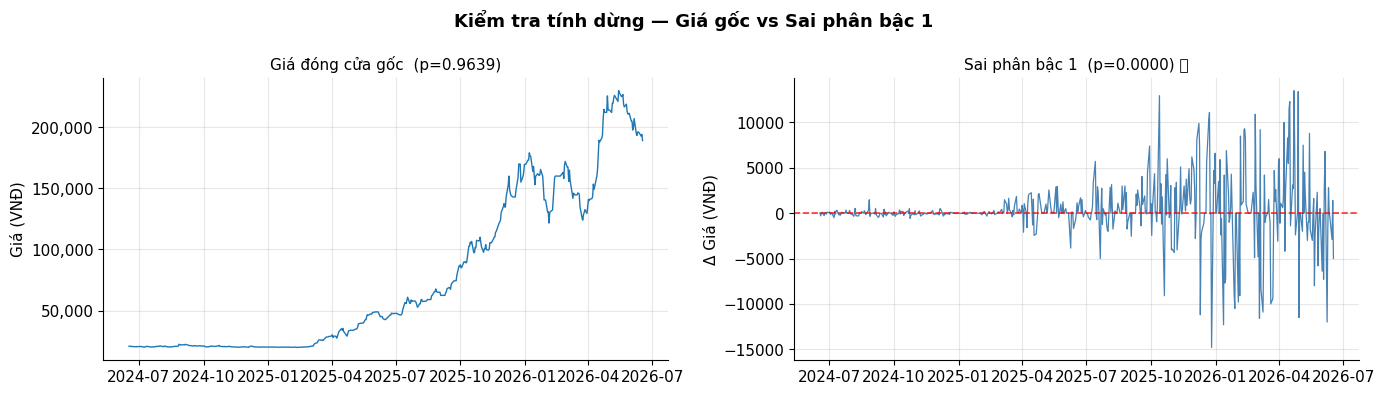

In [4]:
def adf_report(series, label=""):
    """Chạy kiểm định ADF và in kết quả chi tiết."""
    result = adfuller(series, autolag="AIC")
    stat, p_val, lags = result[0], result[1], result[2]
    status = "DỪNG ✅" if p_val < 0.05 else "KHÔNG DỪNG ❌"
    print(f"[ADF — {label}]")
    print(f"  Thống kê ADF : {stat:.4f}")
    print(f"  p-value      : {p_val:.6f}")
    print(f"  Số lags dùng : {lags}")
    print(f"  Kết luận     : {status} (ngưỡng α=0.05)\n")
    return p_val

print("=" * 55)
p_orig = adf_report(df, "Giá đóng cửa gốc")

df_d1 = df.diff().dropna()
p_d1  = adf_report(df_d1, "Sai phân bậc 1  (d=1)")
print("=" * 55)
print(f"→ Bậc sai phân d = {'0 (chuỗi gốc đã dừng)' if p_orig < 0.05 else '1 (cần sai phân 1 lần)'}")

# ── Biểu đồ so sánh giá gốc vs sai phân cạnh nhau ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Kiểm tra tính dừng — Giá gốc vs Sai phân bậc 1", fontsize=13, fontweight="bold")

axes[0].plot(df.index, df.values, lw=1, color="#1f77b4")
axes[0].set_title(f"Giá đóng cửa gốc  (p={p_orig:.4f})", fontsize=11)
axes[0].set_ylabel("Giá (VNĐ)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].plot(df_d1.index, df_d1.values, lw=0.9, color="steelblue")
axes[1].axhline(0, color="red", lw=1.2, ls="--", alpha=0.8)
axes[1].set_title(f"Sai phân bậc 1  (p={p_d1:.4f}) ✅", fontsize=11)
axes[1].set_ylabel("Δ Giá (VNĐ)")

plt.tight_layout()
plt.show()

---
## 3. ACF & PACF → Gợi ý tham số p, q

| Đồ thị | Xác định | Quy tắc đọc |
|---|---|---|
| **ACF** (AutoCorrelation Function) | Tham số `q` của MA | Nếu ACF cắt về 0 ngay sau lag k → `q = k` |
| **PACF** (Partial AutoCorrelation Function) | Tham số `p` của AR | Nếu PACF cắt về 0 ngay sau lag k → `p = k` |

> **Vùng xanh nhạt** = khoảng tin cậy 95%. Các thanh vượt ra ngoài vùng này có ý nghĩa thống kê.
> Đây chỉ là gợi ý ban đầu — Grid Search ở bước tiếp theo sẽ tìm tổ hợp tối ưu theo AIC/BIC.

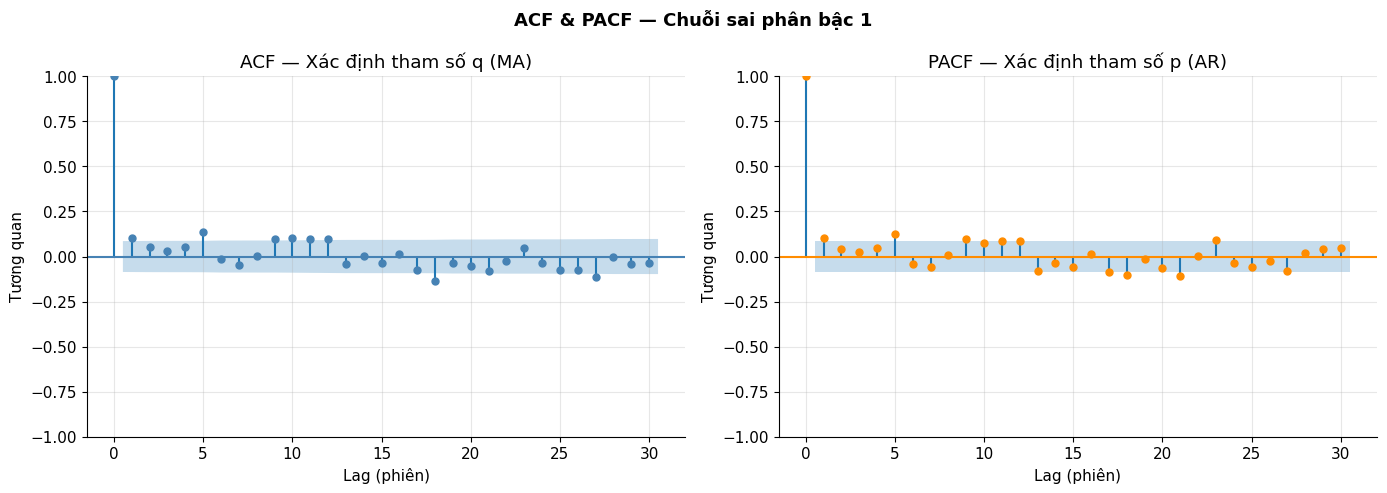


📖 Cách đọc đồ thị:
─────────────────────────────────────────────────
▸ ACF  (AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  MA(k), tức q = k
  → Nếu giảm dần từ từ       →  có thành phần AR

▸ PACF (Partial AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  AR(k), tức p = k
  → Nếu giảm dần từ từ       →  có thành phần MA

▸ Vùng xanh nhạt = khoảng tin cậy 95%.
  Các thanh vượt ra ngoài vùng này là có ý nghĩa thống kê.
─────────────────────────────────────────────────



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ACF & PACF — Chuỗi sai phân bậc 1", fontsize=13, fontweight="bold")

plot_acf(df_d1,  lags=30, ax=axes[0], title="ACF — Xác định tham số q (MA)",  color="steelblue")
plot_pacf(df_d1, lags=30, ax=axes[1], title="PACF — Xác định tham số p (AR)", color="darkorange")

for ax in axes:
    ax.set_xlabel("Lag (phiên)")
    ax.set_ylabel("Tương quan")

plt.tight_layout()
plt.show()

print("""
📖 Cách đọc đồ thị:
─────────────────────────────────────────────────
▸ ACF  (AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  MA(k), tức q = k
  → Nếu giảm dần từ từ       →  có thành phần AR

▸ PACF (Partial AutoCorrelation Function):
  → Nếu cắt về 0 tại lag k  →  AR(k), tức p = k
  → Nếu giảm dần từ từ       →  có thành phần MA

▸ Vùng xanh nhạt = khoảng tin cậy 95%.
  Các thanh vượt ra ngoài vùng này là có ý nghĩa thống kê.
─────────────────────────────────────────────────
""")

---
## 4. Grid-search AIC/BIC → Tìm tham số ARIMA tối ưu

**Cơ chế hoạt động:**
- Duyệt tất cả tổ hợp (p, q) ∈ [0..4]×[0..4] với `d=1` cố định (từ kết quả ADF)
- Fit ARIMA(p, 1, q) và ghi lại **AIC** (Akaike Information Criterion) & **BIC** (Bayesian IC)
- Chọn tổ hợp có **AIC thấp nhất** → cân bằng giữa độ khớp và độ phức tạp mô hình

| Tiêu chí | Công thức | Ý nghĩa |
|---|---|---|
| **AIC** | -2·log(L) + 2k | k = số tham số; cân bằng fit vs complexity |
| **BIC** | -2·log(L) + k·ln(n) | Phạt nặng hơn AIC với mô hình nhiều tham số |

📐 Tập Train: 493 phiên | Tập Test: 30 phiên

🔍 Đang Grid Search (p,q) ∈ [0..4]×[0..4] với d=1 ...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\


📊 Bảng kết quả Grid Search (sắp xếp theo AIC tăng dần):
 p  d  q         AIC         BIC
 2  1  4 9326.914357 9356.303708
 3  1  4 9328.656467 9362.244297
 4  1  2 9329.042369 9358.431720
 3  1  3 9332.312591 9361.701942
 2  1  3 9332.762034 9357.952907
 2  1  2 9333.652873 9354.645266
 4  1  3 9334.922354 9368.510184
 1  1  1 9336.175673 9348.771109
 4  1  4 9336.395145 9374.181453
 1  1  2 9337.128884 9353.922799

🏆 Tốt nhất: ARIMA(2,1,4)  AIC=9326.91  BIC=9356.30


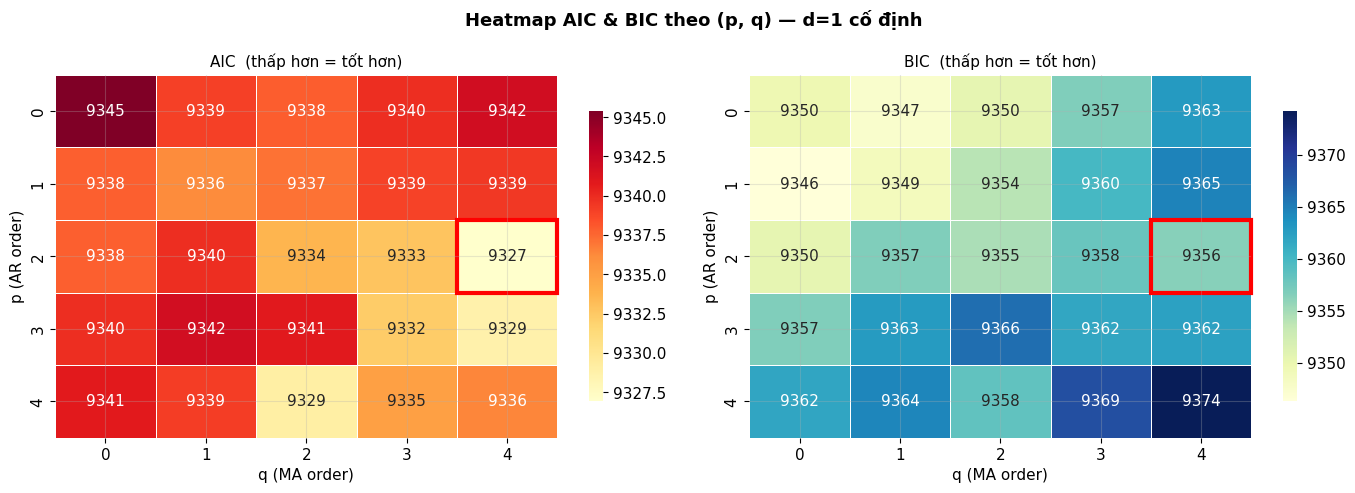

In [6]:
train = df.iloc[:-TEST_SIZE]
print(f"📐 Tập Train: {len(train)} phiên | Tập Test: {TEST_SIZE} phiên\n")
print(f"🔍 Đang Grid Search (p,q) ∈ [0..{P_MAX}]×[0..{Q_MAX}] với d=1 ...")

results = []
for p in range(P_MAX + 1):
    for q in range(Q_MAX + 1):
        try:
            m = ARIMA(train, order=(p, 1, q)).fit()
            results.append({"p": p, "d": 1, "q": q, "AIC": m.aic, "BIC": m.bic})
        except:
            pass

res_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
print("\n📊 Bảng kết quả Grid Search (sắp xếp theo AIC tăng dần):")
print(res_df.head(10).to_string(index=False))

best  = res_df.iloc[0]
p_opt = int(best.p)
d_opt = int(best.d)
q_opt = int(best.q)
print(f"\n🏆 Tốt nhất: ARIMA({p_opt},{d_opt},{q_opt})  AIC={best.AIC:.2f}  BIC={best.BIC:.2f}")

# ── Heatmap AIC & BIC ──────────────────────────────────────────
aic_matrix = res_df.pivot_table(index="p", columns="q", values="AIC")
bic_matrix = res_df.pivot_table(index="p", columns="q", values="BIC")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Heatmap AIC & BIC theo (p, q) — d=1 cố định", fontsize=13, fontweight="bold")

for ax, matrix, title, cmap in zip(
    axes,
    [aic_matrix, bic_matrix],
    ["AIC  (thấp hơn = tốt hơn)", "BIC  (thấp hơn = tốt hơn)"],
    ["YlOrRd", "YlGnBu"]
):
    sns.heatmap(matrix, ax=ax, annot=True, fmt=".0f", cmap=cmap,
                linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("q (MA order)")
    ax.set_ylabel("p (AR order)")
    ax.add_patch(plt.Rectangle((q_opt, p_opt), 1, 1, fill=False,
                                edgecolor="red", lw=3, clip_on=False))

plt.tight_layout()
plt.show()

---
## 5. Fit mô hình AR, MA, ARIMA

Ba mô hình baseline theo yêu cầu bài tập:

| Mô hình | Công thức | Ý nghĩa |
|---|---|---|
| **AR(p)** | `ARIMA(p_opt, 1, 0)` | Tự hồi quy thuần túy: yₜ phụ thuộc vào p giá trị quá khứ |
| **MA(q)** | `ARIMA(0, 1, q_opt)` | Trung bình trượt thuần túy: yₜ phụ thuộc vào q sai số quá khứ |
| **ARIMA(p,d,q)** | Tổ hợp AIC tốt nhất | Kết hợp AR + sai phân + MA |

In [7]:
# ── Huấn luyện 3 mô hình (AR, MA, ARIMA) ─────────────────────
ar_model    = ARIMA(train, order=(p_opt, 1, 0)).fit()
ma_model    = ARIMA(train, order=(0, 1, q_opt)).fit()
arima_model = ARIMA(train, order=(p_opt, d_opt, q_opt)).fit()

models_fitted = {"AR": ar_model, "MA": ma_model, "ARIMA": arima_model}
orders = {
    "AR":    (p_opt, 1, 0),
    "MA":    (0, 1, q_opt),
    "ARIMA": (p_opt, d_opt, q_opt),
}

# ── Bảng so sánh AIC/BIC/Log-Likelihood ──────────────────────
print(f"{'Mô hình':<10} {'Order':<15} {'AIC':>10} {'BIC':>10} {'Log-Lik':>12}")
print("─" * 62)
for name, m in models_fitted.items():
    o = orders[name]
    print(f"{name:<10} ARIMA{str(o):<11} {m.aic:>10.2f} {m.bic:>10.2f} {m.llf:>12.2f}")

# ── In summary mô hình ARIMA tốt nhất ────────────────────────
print(f"\n{'='*60}")
print(f"📋 Model Summary — ARIMA({p_opt},{d_opt},{q_opt}) [Tốt nhất theo AIC]")
print(f"{'='*60}")
print(arima_model.summary())

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

Mô hình    Order                  AIC        BIC      Log-Lik
──────────────────────────────────────────────────────────────
AR         ARIMA(2, 1, 0)      9337.84    9350.44     -4665.92
MA         ARIMA(0, 1, 4)      9341.89    9362.88     -4665.94
ARIMA      ARIMA(2, 1, 4)      9326.91    9356.30     -4656.46

📋 Model Summary — ARIMA(2,1,4) [Tốt nhất theo AIC]
                               SARIMAX Results                                
Dep. Variable:                 VIC.VN   No. Observations:                  493
Model:                 ARIMA(2, 1, 4)   Log Likelihood               -4656.457
Date:                Wed, 17 Jun 2026   AIC                           9326.914
Time:                        13:50:29   BIC                           9356.304
Sample:                    06-17-2024   HQIC                          9338.455
                         - 05-06-2026                                         
Covariance Type:                  opg                                         
  

---
## 6. Backtest 30 phiên cuối — Rolling Forecast

**Walk-Forward / Rolling Forecast:**
- Tại mỗi bước `i`, dùng dữ liệu từ đầu đến trước điểm test thứ `i`
- Fit lại mô hình hoàn toàn → dự báo 1 bước → lặp lại
- ❌ **Không dùng dữ liệu tương lai** — đây là tiêu chí nghiêm ngặt nhất của backtesting

**Chỉ số đánh giá:**

| Chỉ số | Ý nghĩa |
|---|---|
| **MAE** | Mean Absolute Error — sai lệch tuyệt đối trung bình (đơn vị: VNĐ) |
| **RMSE** | Root Mean Square Error — phạt nặng các sai lệch lớn |
| **MAPE** | Mean Absolute Percentage Error — sai số %; **mục tiêu: < 5%** |

In [8]:
test  = df.iloc[-TEST_SIZE:]
preds = {}

print("⏳ Đang thực hiện Rolling Forecast (mỗi bước fit lại mô hình)...")
print(f"   Test: {TEST_SIZE} phiên | {test.index[0].date()} → {test.index[-1].date()}\n")

for name, order in orders.items():
    fc = []
    for i in range(TEST_SIZE):
        window_data = df.iloc[:-(TEST_SIZE - i)] if i < TEST_SIZE else df
        m = ARIMA(window_data, order=order).fit()
        fc.append(m.forecast(1).iloc[0])
    preds[name] = pd.Series(fc, index=test.index)
    print(f"  ✅ {name} xong")

# ── Đánh giá ─────────────────────────────────────────────────
metrics = {}
print(f"\n{'─'*52}")
print(f"{'Mô hình':<10} {'MAE (VNĐ)':>12} {'RMSE (VNĐ)':>13} {'MAPE (%)':>10}")
print(f"{'─'*52}")
for name, pred in preds.items():
    mae  = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mape = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    metrics[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}
    print(f"{name:<10} {mae:>12,.1f} {rmse:>13,.1f} {mape:>10.2f}%")

print(f"{'─'*52}")
best_model = min(metrics, key=lambda k: metrics[k]["MAPE"])
print(f"🏆 Mô hình tốt nhất: {best_model}  (MAPE={metrics[best_model]['MAPE']:.2f}%)")

⏳ Đang thực hiện Rolling Forecast (mỗi bước fit lại mô hình)...
   Test: 30 phiên | 2026-05-07 → 2026-06-17



d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  ✅ AR xong


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  ✅ MA xong


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

  ✅ ARIMA xong

────────────────────────────────────────────────────
Mô hình       MAE (VNĐ)    RMSE (VNĐ)   MAPE (%)
────────────────────────────────────────────────────
AR              3,391.3       4,549.5       1.62%
MA              3,366.3       4,556.1       1.61%
ARIMA           3,290.7       4,554.5       1.58%
────────────────────────────────────────────────────
🏆 Mô hình tốt nhất: ARIMA  (MAPE=1.58%)


---
## 7. Biểu đồ Backtest — 3 mô hình

Mỗi panel hiển thị:
- **Đường đen đậm**: Giá thực tế
- **Đường màu đứt**: Dự báo của từng mô hình
- **Vùng fill**: Khu vực sai số (sai lệch giữa thực tế và dự báo)
- **Label**: MAE và MAPE trực tiếp trên biểu đồ

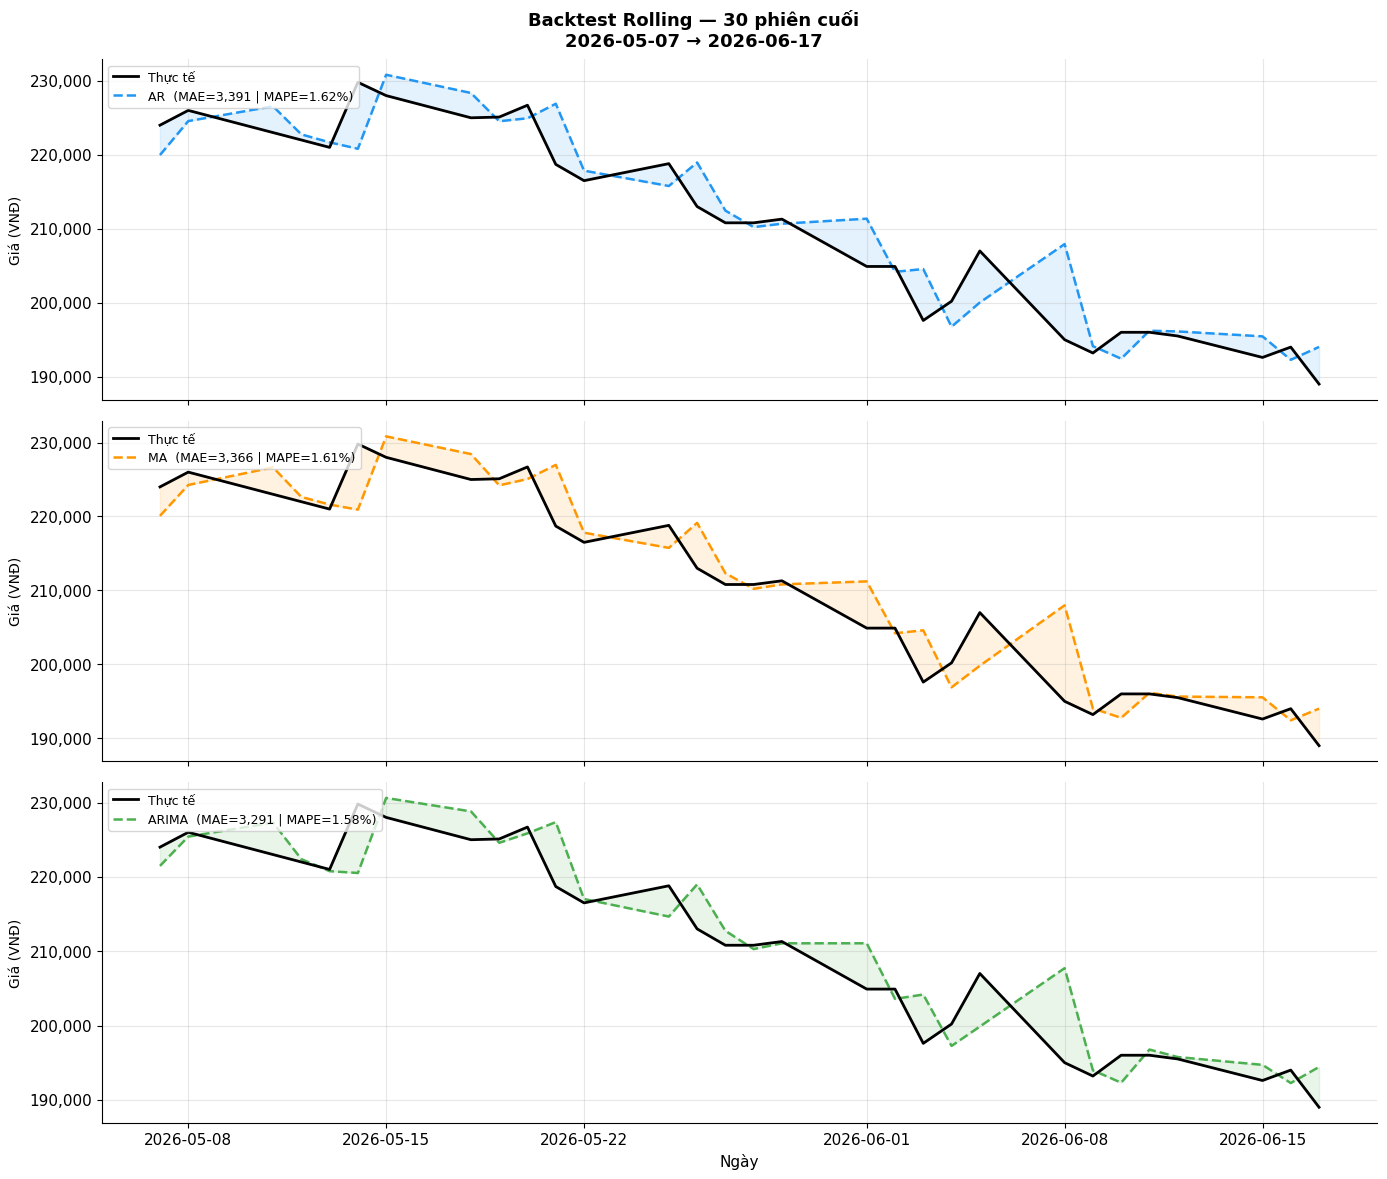

In [9]:
colors = {"AR": "#2196F3", "MA": "#FF9800", "ARIMA": "#4CAF50"}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Backtest Rolling — {TEST_SIZE} phiên cuối\n"
             f"{test.index[0].date()} → {test.index[-1].date()}",
             fontsize=13, fontweight="bold")

for ax, (name, pred) in zip(axes, preds.items()):
    m = metrics[name]
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế", zorder=3)
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=colors[name],
            label=f"{name}  (MAE={m['MAE']:,.0f} | MAPE={m['MAPE']:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values,
                    alpha=0.12, color=colors[name])
    ax.set_ylabel("Giá (VNĐ)", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[-1].set_xlabel("Ngày")
plt.tight_layout()
plt.show()

---
## 8. So sánh hiệu suất 3 mô hình baseline

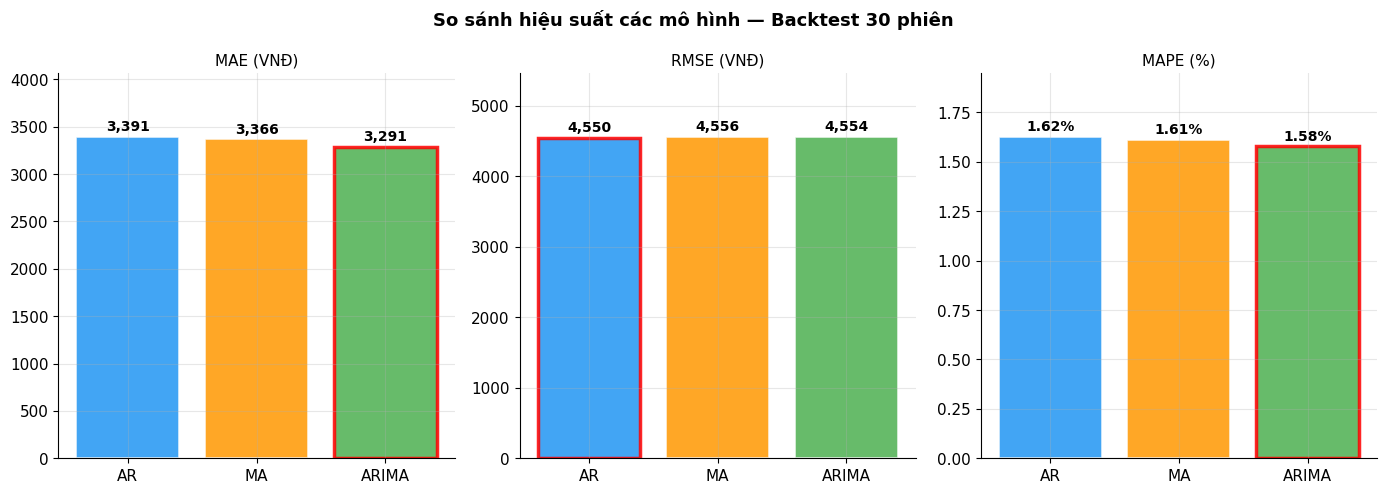

In [10]:
metric_names = ["MAE", "RMSE", "MAPE"]
model_names  = list(metrics.keys())
bar_colors   = ["#2196F3", "#FF9800", "#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("So sánh hiệu suất các mô hình — Backtest 30 phiên",
             fontsize=13, fontweight="bold")

for ax, metric in zip(axes, metric_names):
    vals     = [metrics[m][metric] for m in model_names]
    bars     = ax.bar(model_names, vals, color=bar_colors, alpha=0.85,
                      edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, vals):
        label = f"{val:.2f}%" if metric == "MAPE" else f"{val:,.0f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                label, ha="center", va="bottom", fontsize=10, fontweight="bold")
    best_idx = np.argmin(vals)
    bars[best_idx].set_edgecolor("red")
    bars[best_idx].set_linewidth(2.5)
    unit = "%" if metric == "MAPE" else "VNĐ"
    ax.set_title(f"{metric} ({unit})", fontsize=11)
    ax.set_ylim(0, max(vals) * 1.2)

plt.tight_layout()
plt.show()

---
## 9. Dự báo 10 ngày tiếp theo (3 mô hình)

**Quy trình:**
1. Fit lại mô hình trên **toàn bộ dữ liệu** (không chỉ train)
2. Dự báo 10 bước tới với **khoảng tin cậy 95%**
3. Tạo ngày làm việc tiếp theo bằng `pd.bdate_range` (bỏ qua thứ 7, CN)
4. Bảng kết quả kèm Δ% so với giá hôm nay

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

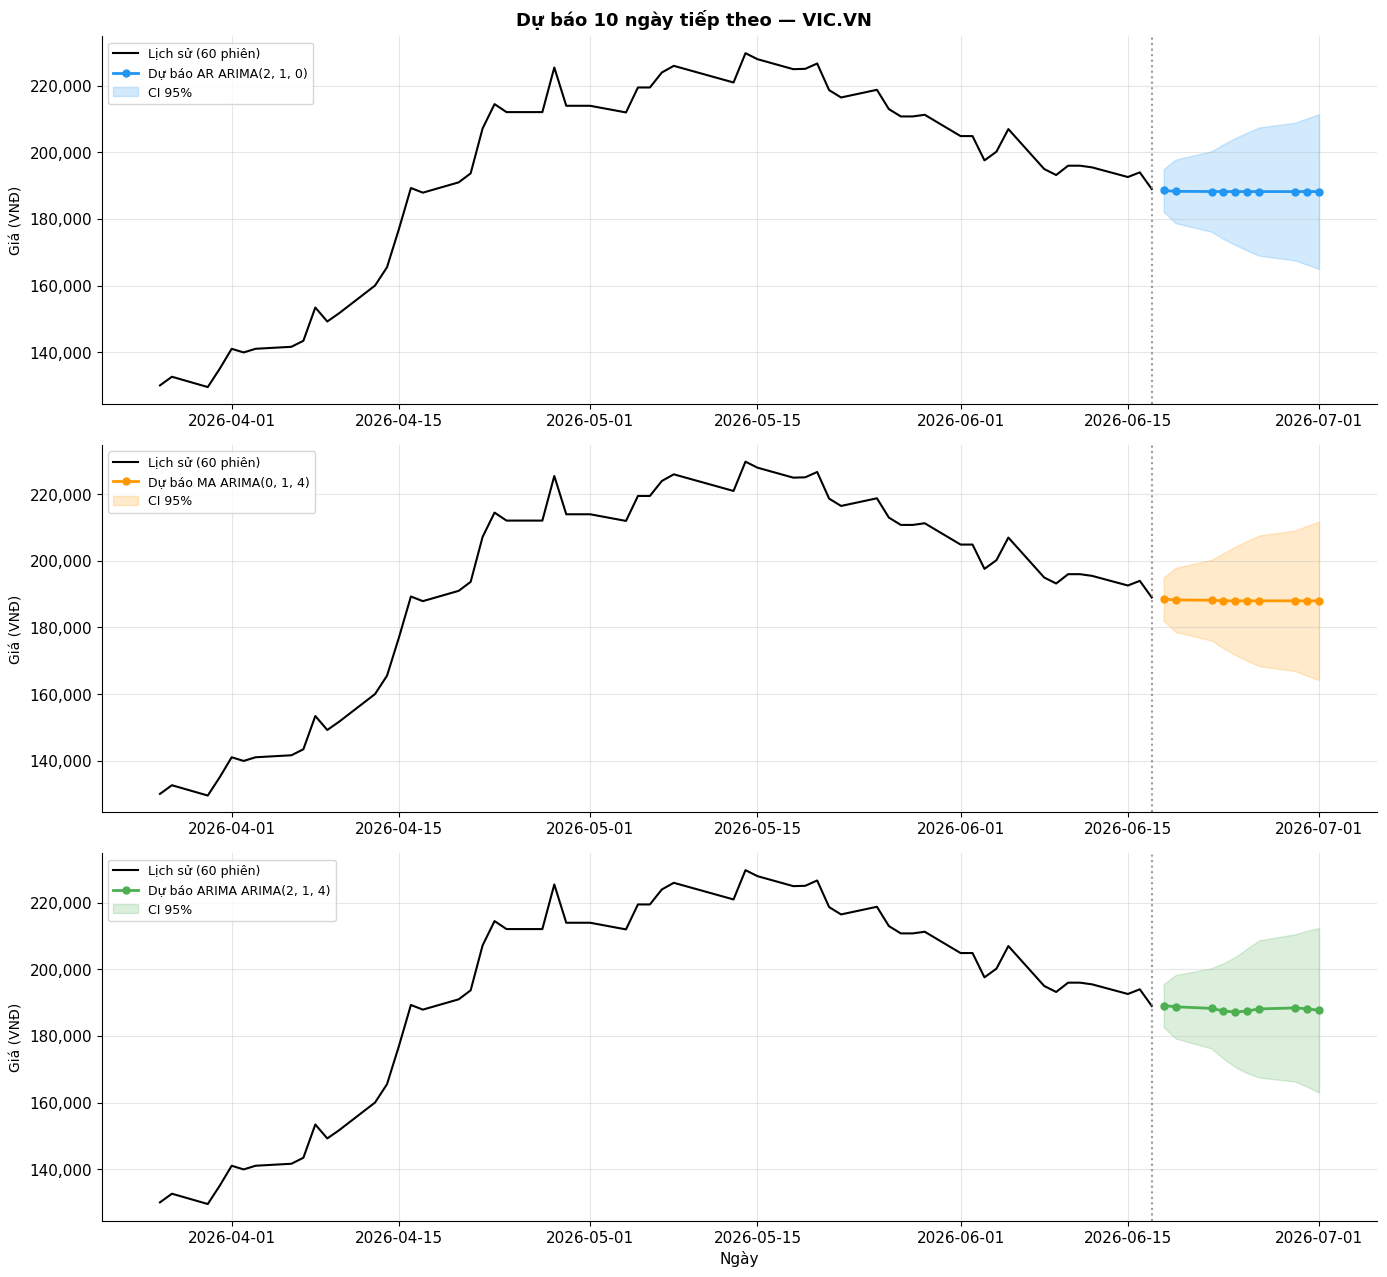


📅 Bảng giá dự báo 10 ngày tới:

── AR ARIMA(2, 1, 0) ──
      Ngày  Giá dự báo  Δ% so hôm nay  CI Lower (95%)  CI Upper (95%)
2026-06-18      188558          -0.23          182134          194983
2026-06-19      188295          -0.37          178741          197848
2026-06-22      188249          -0.40          176153          200344
2026-06-23      188233          -0.41          174011          202454
2026-06-24      188229          -0.41          172150          204308
2026-06-25      188228          -0.41          170482          205973
2026-06-26      188228          -0.41          168959          207496
2026-06-29      188228          -0.41          167547          208908
2026-06-30      188227          -0.41          166226          210229
2026-07-01      188227          -0.41          164980          211475

── MA ARIMA(0, 1, 4) ──
      Ngày  Giá dự báo  Δ% so hôm nay  CI Lower (95%)  CI Upper (95%)
2026-06-18      188540          -0.24          182030          195049
2026-06-

In [11]:
# ── Fit lại trên toàn bộ dữ liệu ─────────────────────────────
last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST)

forecasts = {}
for name, order in orders.items():
    m       = ARIMA(df, order=order).fit()
    res     = m.get_forecast(steps=FORECAST)
    fc_mean = res.predicted_mean
    fc_ci   = res.conf_int(alpha=0.05)
    fc_mean.index = future_dates
    fc_ci.index   = future_dates
    forecasts[name] = {"mean": fc_mean, "ci": fc_ci, "model": m}

# ── Biểu đồ dự báo 3 mô hình ─────────────────────────────────
n_hist = 60
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)
fig.suptitle(f"Dự báo 10 ngày tiếp theo — {TICKER}", fontsize=13, fontweight="bold")

for ax, (name, fc) in zip(axes, forecasts.items()):
    color = colors[name]
    ax.plot(df.index[-n_hist:], df.values[-n_hist:],
            "k-", lw=1.5, label=f"Lịch sử ({n_hist} phiên)")
    ax.plot(fc["mean"].index, fc["mean"].values,
            "o-", lw=2.0, ms=5, color=color,
            label=f"Dự báo {name} ARIMA{orders[name]}")
    ax.fill_between(fc["ci"].index,
                    fc["ci"].iloc[:, 0], fc["ci"].iloc[:, 1],
                    alpha=0.20, color=color, label="CI 95%")
    ax.axvline(last_date, color="gray", ls=":", lw=1.5, alpha=0.8)
    ax.set_ylabel("Giá (VNĐ)", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[-1].set_xlabel("Ngày")
plt.tight_layout()
plt.show()

# ── Bảng giá dự báo chi tiết (kèm Δ% so hôm nay) ────────────
print("\n📅 Bảng giá dự báo 10 ngày tới:\n")
today_price = df.iloc[-1]

for name, fc in forecasts.items():
    print(f"── {name} ARIMA{orders[name]} ──")
    tbl = pd.DataFrame({
        "Ngày":            fc["mean"].index.date,
        "Giá dự báo":      fc["mean"].values.round(0).astype(int),
        "Δ% so hôm nay":   ((fc["mean"].values / today_price - 1) * 100).round(2),
        "CI Lower (95%)": fc["ci"].iloc[:, 0].values.round(0).astype(int),
        "CI Upper (95%)": fc["ci"].iloc[:, 1].values.round(0).astype(int),
    })
    print(tbl.to_string(index=False))
    print()

---
## 10. Phân tích Residuals (Phần dư)

Kiểm tra phần dư của mô hình tốt nhất qua 4 biểu đồ:

| Biểu đồ | Mô hình tốt khi... |
|---|---|
| **Residuals theo thời gian** | Phân bố ngẫu nhiên quanh 0, không có pattern |
| **Histogram** | Cân đối, gần phân phối chuẩn |
| **ACF Residuals** | Tất cả lag nằm trong khoảng tin cậy 95% |
| **Q-Q Plot** | Các điểm nằm sát đường đỏ thẳng |

**Kiểm định Ljung-Box:** p-value > 0.05 tại mọi lag → phần dư là **nhiễu trắng** ✅ (mô hình đã nắm bắt hết cấu trúc)

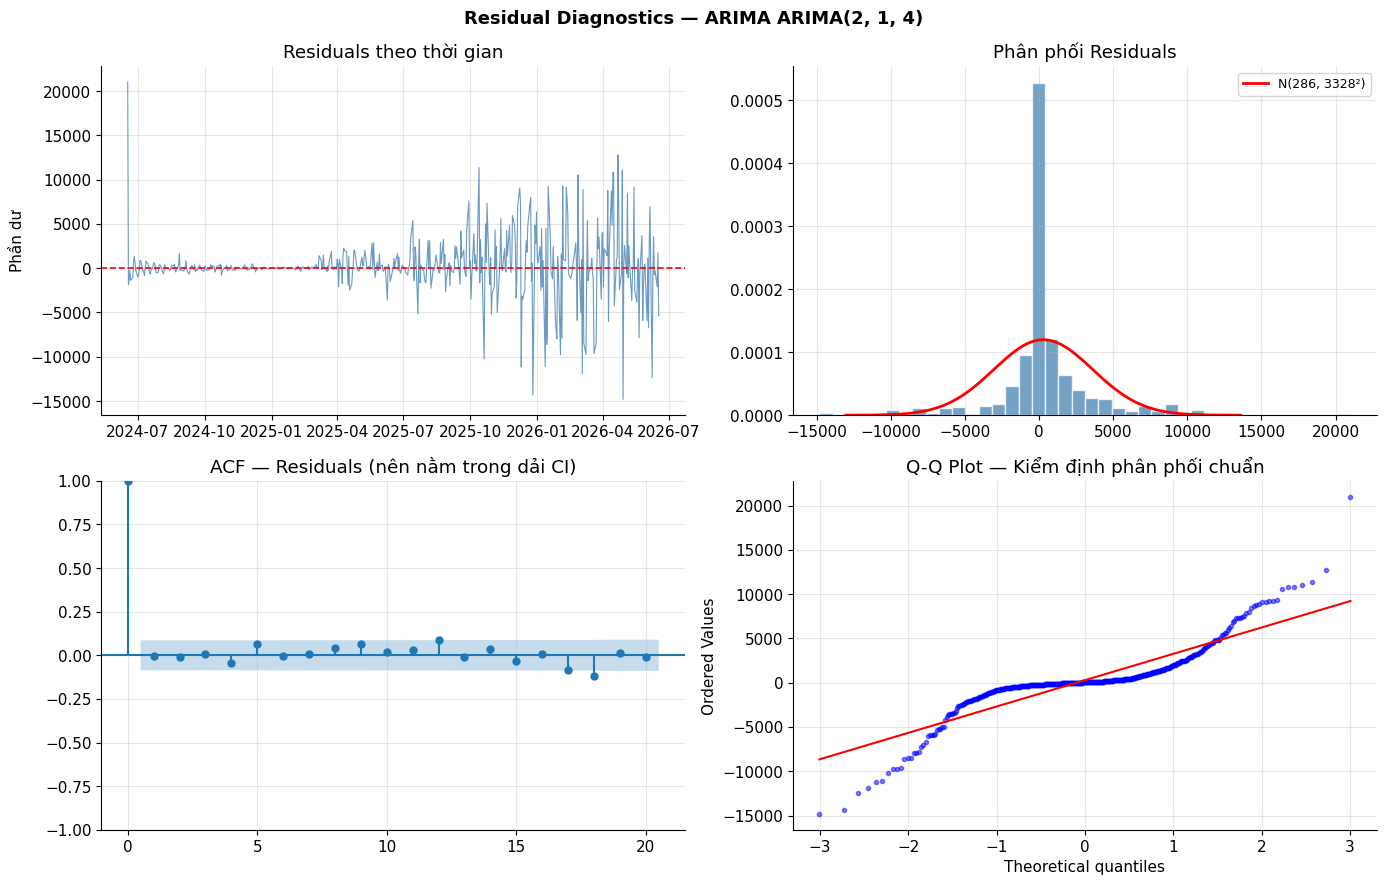


📋 Ljung-Box Test (kiểm định tự tương quan phần dư):
      lb_stat  lb_pvalue
10   7.058616   0.719900
20  24.160452   0.235454

  Lag 10: p-value = 0.7199  →  ✅ Không tự tương quan (mô hình tốt)
  Lag 20: p-value = 0.2355  →  ✅ Không tự tương quan (mô hình tốt)


In [12]:
final_model = forecasts[best_model]["model"]
residuals   = final_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"Residual Diagnostics — {best_model} ARIMA{orders[best_model]}",
             fontsize=13, fontweight="bold")

# 1. Residuals theo thời gian
axes[0, 0].plot(residuals.index, residuals.values, lw=0.8, color="steelblue", alpha=0.8)
axes[0, 0].axhline(0, color="red", ls="--", lw=1.2)
axes[0, 0].set_title("Residuals theo thời gian")
axes[0, 0].set_ylabel("Phần dư")

# 2. Histogram + đường chuẩn
axes[0, 1].hist(residuals, bins=40, color="steelblue", edgecolor="white",
                density=True, alpha=0.75)
mu, sigma = residuals.mean(), residuals.std()
x_range   = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
axes[0, 1].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
                "r-", lw=2, label=f"N({mu:.0f}, {sigma:.0f}²)")
axes[0, 1].set_title("Phân phối Residuals")
axes[0, 1].legend(fontsize=9)

# 3. ACF của residuals
plot_acf(residuals, lags=20, ax=axes[1, 0],
         title="ACF — Residuals (nên nằm trong dải CI)")

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot — Kiểm định phân phối chuẩn")
axes[1, 1].get_lines()[0].set(markersize=3, alpha=0.5)
axes[1, 1].get_lines()[1].set(color="red", lw=1.5)

plt.tight_layout()
plt.show()

# ── Ljung-Box Test ────────────────────────────────────────────
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("\n📋 Ljung-Box Test (kiểm định tự tương quan phần dư):")
print(lb.to_string())
print()
for lag in [10, 20]:
    p = lb.loc[lag, "lb_pvalue"]
    status = "✅ Không tự tương quan (mô hình tốt)" if p > 0.05 else "❌ Còn tự tương quan"
    print(f"  Lag {lag:2d}: p-value = {p:.4f}  →  {status}")

---
## 11. Kết luận — Mô hình truyền thống (AR / MA / ARIMA)

In [13]:
print("=" * 65)
print(f"  KẾT LUẬN — Phân tích chuỗi thời gian {TICKER}")
print("=" * 65)
print(f"\n  Dữ liệu  : {len(df)} phiên | {df.index[0].date()} → {df.index[-1].date()}")
print(f"  Backtest : {TEST_SIZE} phiên rolling forecast\n")

print(f"  {'Mô hình':<14} {'Order':<15} {'MAE':>10} {'RMSE':>10} {'MAPE':>9}")
print(f"  {'─'*62}")
for name in list(metrics.keys()):
    m   = metrics[name]
    tag = " ← 🏆 Best" if name == best_model else ""
    print(f"  {name:<14} {str(orders[name]):<15} "
          f"{m['MAE']:>10,.0f} {m['RMSE']:>10,.0f} {m['MAPE']:>8.2f}%{tag}")

print(f"\n  Mô hình tốt nhất: {best_model} ARIMA{orders[best_model]}")
mape_best = metrics[best_model]['MAPE']
verdict   = "✅ ĐẠT mục tiêu MAPE < 5%" if mape_best < 5 else "⚠️ CHƯA đạt mục tiêu MAPE < 5%"
print(f"  MAPE = {mape_best:.2f}%  {verdict}")
print("\n" + "=" * 65)

  KẾT LUẬN — Phân tích chuỗi thời gian VIC.VN

  Dữ liệu  : 523 phiên | 2024-06-17 → 2026-06-17
  Backtest : 30 phiên rolling forecast

  Mô hình        Order                  MAE       RMSE      MAPE
  ──────────────────────────────────────────────────────────────
  AR             (2, 1, 0)            3,391      4,550     1.62%
  MA             (0, 1, 4)            3,366      4,556     1.61%
  ARIMA          (2, 1, 4)            3,291      4,554     1.58% ← 🏆 Best

  Mô hình tốt nhất: ARIMA ARIMA(2, 1, 4)
  MAPE = 1.58%  ✅ ĐẠT mục tiêu MAPE < 5%



---
# ═══════════════════════════════════════════════════
# CẤP ĐỘ 2 — OPTUNA-ARIMA (Out-of-sample Optimization)
# ═══════════════════════════════════════════════════

## 12. Tối ưu hóa siêu tham số Out-of-sample với Optuna

**Vấn đề của Auto-ARIMA (AIC):**
- AIC tối ưu hóa trên **dữ liệu huấn luyện** → dễ overfitting → mô hình tốt với quá khứ nhưng kém với tương lai

**Giải pháp — Optuna (TPE Sampler):**
- Tách riêng **10% dữ liệu** làm `Validation Set` ẩn
- Optuna dùng **Bayesian Optimization (TPE)** để tìm (p, d, q) tối thiểu hóa **RMSE trên Val Set**
- Tức là tìm mô hình *tốt nhất cho tương lai*, không phải tốt nhất cho quá khứ

```
  ┌─────────────────────────────────────────────────┐
  │  Train (80%)  │  Val (10%)  │  Test (10%) - ẩn  │
  └─────────────────────────────────────────────────┘
        Fit model    Optuna tối ưu   Evaluate cuối
```

📐 Phân chia dữ liệu cho Optuna:
   Train  : 444 phiên (2024-06-17 → 2026-02-26)
   Val    : 49 phiên  (2026-02-27 → 2026-05-06)
   Test   : 30 phiên (2026-05-07 → 2026-06-17)

🔍 Đang tìm kiếm tham số tối ưu bằng Optuna (TPE Sampler)...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✅ Tốt nhất: ARIMA(0,2,1)  Val-RMSE=30,282.8 VNĐ

📊 So sánh chiến lược tối ưu:
   Auto-ARIMA  (AIC):       ARIMA(2,1,4)
   Optuna-ARIMA (Val-RMSE): ARIMA(0,2,1)


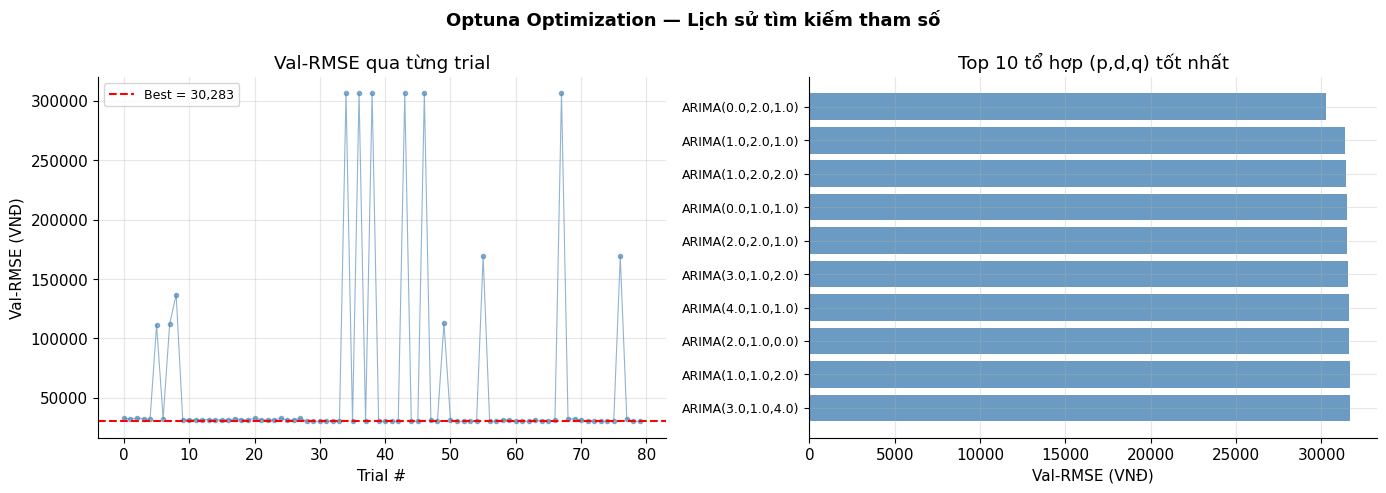

In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Chia dữ liệu: Train / Validation / Test ────────────────────
n_total      = len(df) - TEST_SIZE
n_val        = int(n_total * 0.10)
n_train_opt  = n_total - n_val

train_opt = df.iloc[:n_train_opt]
val_opt   = df.iloc[n_train_opt:n_total]
test_opt  = df.iloc[-TEST_SIZE:]

print(f"📐 Phân chia dữ liệu cho Optuna:")
print(f"   Train  : {len(train_opt)} phiên ({train_opt.index[0].date()} → {train_opt.index[-1].date()})")
print(f"   Val    : {len(val_opt)} phiên  ({val_opt.index[0].date()} → {val_opt.index[-1].date()})")
print(f"   Test   : {len(test_opt)} phiên ({test_opt.index[0].date()} → {test_opt.index[-1].date()})")

# ── Hàm objective: minimize RMSE trên Validation Set ──────────
def optuna_objective(trial):
    p = trial.suggest_int("p", 0, P_MAX)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, Q_MAX)
    try:
        m    = ARIMA(train_opt, order=(p, d, q)).fit()
        pred = m.forecast(steps=len(val_opt))
        rmse = np.sqrt(mean_squared_error(val_opt, pred))
        return rmse
    except:
        return 1e9   # Mô hình không hội tụ → phạt nặng

# ── Chạy Optuna ───────────────────────────────────────────────
print("\n🔍 Đang tìm kiếm tham số tối ưu bằng Optuna (TPE Sampler)...")
study = optuna.create_study(direction="minimize",
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(optuna_objective, n_trials=80, show_progress_bar=False)

best_params = study.best_params
p_opt2 = best_params["p"]
d_opt2 = best_params["d"]
q_opt2 = best_params["q"]
print(f"✅ Tốt nhất: ARIMA({p_opt2},{d_opt2},{q_opt2})  Val-RMSE={study.best_value:,.1f} VNĐ")

print(f"\n📊 So sánh chiến lược tối ưu:")
print(f"   Auto-ARIMA  (AIC):       ARIMA({p_opt},{d_opt},{q_opt})")
print(f"   Optuna-ARIMA (Val-RMSE): ARIMA({p_opt2},{d_opt2},{q_opt2})")

# ── Biểu đồ Optuna Optimization History ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optuna Optimization — Lịch sử tìm kiếm tham số", fontsize=13, fontweight="bold")

trial_vals = [t.value for t in study.trials if t.value < 1e8]
axes[0].plot(trial_vals, "o-", ms=3, lw=0.8, color="steelblue", alpha=0.6)
axes[0].axhline(study.best_value, color="red", ls="--", lw=1.5,
                label=f"Best = {study.best_value:,.0f}")
axes[0].set_title("Val-RMSE qua từng trial")
axes[0].set_xlabel("Trial #")
axes[0].set_ylabel("Val-RMSE (VNĐ)")
axes[0].legend(fontsize=9)

param_df = pd.DataFrame([t.params for t in study.trials if t.value < 1e8])
param_df["rmse"] = trial_vals
best_per_order = param_df.groupby(["p", "d", "q"])["rmse"].min().reset_index()
best_per_order = best_per_order.sort_values("rmse").head(10)
axes[1].barh(range(len(best_per_order)),
             best_per_order["rmse"].values,
             color="steelblue", alpha=0.8)
axes[1].set_yticks(range(len(best_per_order)))
axes[1].set_yticklabels([f"ARIMA({r.p},{r.d},{r.q})"
                          for _, r in best_per_order.iterrows()], fontsize=9)
axes[1].set_title("Top 10 tổ hợp (p,d,q) tốt nhất")
axes[1].set_xlabel("Val-RMSE (VNĐ)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

⏳ Optuna-ARIMA(0,2,1) Rolling Forecast...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✅ MAPE=1.66%  MAE=3,462  RMSE=4,569


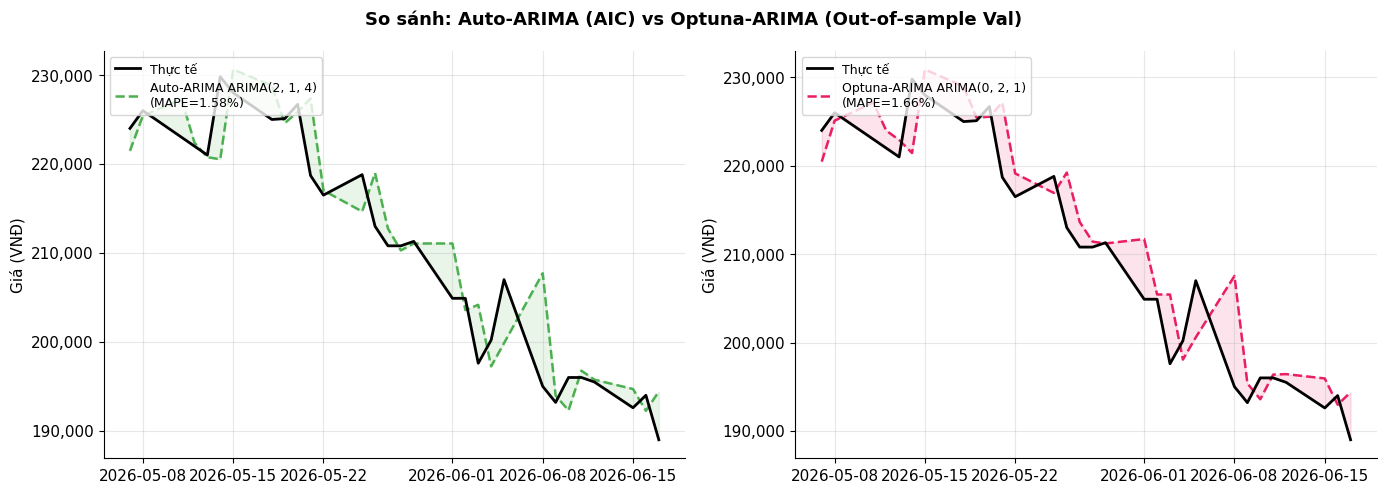


📊 Kết quả so sánh:
   Auto-ARIMA   : MAPE=1.58% (tối ưu theo AIC — in-sample)
   Optuna-ARIMA : MAPE=1.66% (tối ưu theo RMSE — out-of-sample)
   → Tối ưu out-of-sample không cải thiện so với Auto-ARIMA



In [15]:
# ── Rolling Forecast Optuna-ARIMA ─────────────────────────────
print(f"⏳ Optuna-ARIMA({p_opt2},{d_opt2},{q_opt2}) Rolling Forecast...")
fc_optuna = []
for i in range(TEST_SIZE):
    wd = df.iloc[:-(TEST_SIZE - i)]
    m  = ARIMA(wd, order=(p_opt2, d_opt2, q_opt2)).fit()
    fc_optuna.append(m.forecast(1).iloc[0])

pred_optuna = pd.Series(fc_optuna, index=test.index)
mae_opt  = mean_absolute_error(test, pred_optuna)
rmse_opt = np.sqrt(mean_squared_error(test, pred_optuna))
mape_opt = np.mean(np.abs((test.values - pred_optuna.values) / test.values)) * 100
metrics["Optuna-ARIMA"] = {"MAE": mae_opt, "RMSE": rmse_opt, "MAPE": mape_opt}
print(f"✅ MAPE={mape_opt:.2f}%  MAE={mae_opt:,.0f}  RMSE={rmse_opt:,.0f}")

# ── Biểu đồ so sánh: Auto-ARIMA vs Optuna-ARIMA ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh: Auto-ARIMA (AIC) vs Optuna-ARIMA (Out-of-sample Val)",
             fontsize=13, fontweight="bold")

for ax, (name, pred, color) in zip(axes, [
    (f"Auto-ARIMA ARIMA{(p_opt,d_opt,q_opt)}", preds["ARIMA"], "#4CAF50"),
    (f"Optuna-ARIMA ARIMA{(p_opt2,d_opt2,q_opt2)}", pred_optuna, "#E91E63"),
]):
    mape_v = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế", zorder=3)
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=color,
            label=f"{name}\n(MAPE={mape_v:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values, alpha=0.12, color=color)
    ax.set_ylabel("Giá (VNĐ)")
    ax.legend(fontsize=9, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

print(f"""
📊 Kết quả so sánh:
   Auto-ARIMA   : MAPE={metrics['ARIMA']['MAPE']:.2f}% (tối ưu theo AIC — in-sample)
   Optuna-ARIMA : MAPE={mape_opt:.2f}% (tối ưu theo RMSE — out-of-sample)
   → Tối ưu out-of-sample {'CẢI THIỆN' if mape_opt < metrics['ARIMA']['MAPE'] else 'không cải thiện so'} với Auto-ARIMA
""")

---
# ═══════════════════════════════════════════════════
# CẤP ĐỘ 3 — META PROPHET (Decomposable Time Series)
# ═══════════════════════════════════════════════════

## 13. Meta Prophet — Mô hình phân rã chuỗi thời gian

**Ưu điểm so với ARIMA:**
- Không yêu cầu chuỗi phải dừng (stationary)
- Phát hiện **Trend Changepoints** — điểm gãy xu hướng đặc trưng của TTCK
- Tự động xử lý **seasonality** (tuần, năm)

**Công thức Prophet:** y(t) = g(t) + s(t) + h(t) + εₜ
- g(t): Xu hướng (trend) — tuyến tính hoặc logistic
- s(t): Thành phần mùa vụ (seasonality)
- h(t): Tác động ngày lễ (holidays)
- εₜ: Nhiễu ngẫu nhiên

In [16]:
from prophet import Prophet

# ── Chuẩn bị dữ liệu theo định dạng Prophet ───────────────────
df_prophet = df.reset_index()
df_prophet.columns = ["ds", "y"]
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

train_prophet = df_prophet.iloc[:-TEST_SIZE]
test_prophet  = df_prophet.iloc[-TEST_SIZE:]

print(f"📐 Train Prophet: {len(train_prophet)} phiên")
print(f"   Test Prophet : {len(test_prophet)} phiên")

# ── Fit Prophet ───────────────────────────────────────────────
prophet_model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)
prophet_model.fit(train_prophet)
print("✅ Prophet fit xong")

# ── Dự báo trên test period ───────────────────────────────────
future_prophet   = prophet_model.make_future_dataframe(periods=TEST_SIZE, freq="B")
forecast_prophet = prophet_model.predict(future_prophet)
pred_prophet_raw = forecast_prophet.iloc[-TEST_SIZE:]["yhat"].values
pred_prophet     = pd.Series(pred_prophet_raw, index=test.index)

mae_prp  = mean_absolute_error(test, pred_prophet)
rmse_prp = np.sqrt(mean_squared_error(test, pred_prophet))
mape_prp = np.mean(np.abs((test.values - pred_prophet.values) / test.values)) * 100
metrics["Prophet"] = {"MAE": mae_prp, "RMSE": rmse_prp, "MAPE": mape_prp}
print(f"📊 Prophet — MAE={mae_prp:,.0f} | RMSE={rmse_prp:,.0f} | MAPE={mape_prp:.2f}%")

Importing plotly failed. Interactive plots will not work.


📐 Train Prophet: 493 phiên
   Test Prophet : 30 phiên


13:51:28 - cmdstanpy - INFO - Chain [1] start processing
13:51:29 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet fit xong
📊 Prophet — MAE=12,070 | RMSE=14,014 | MAPE=5.83%


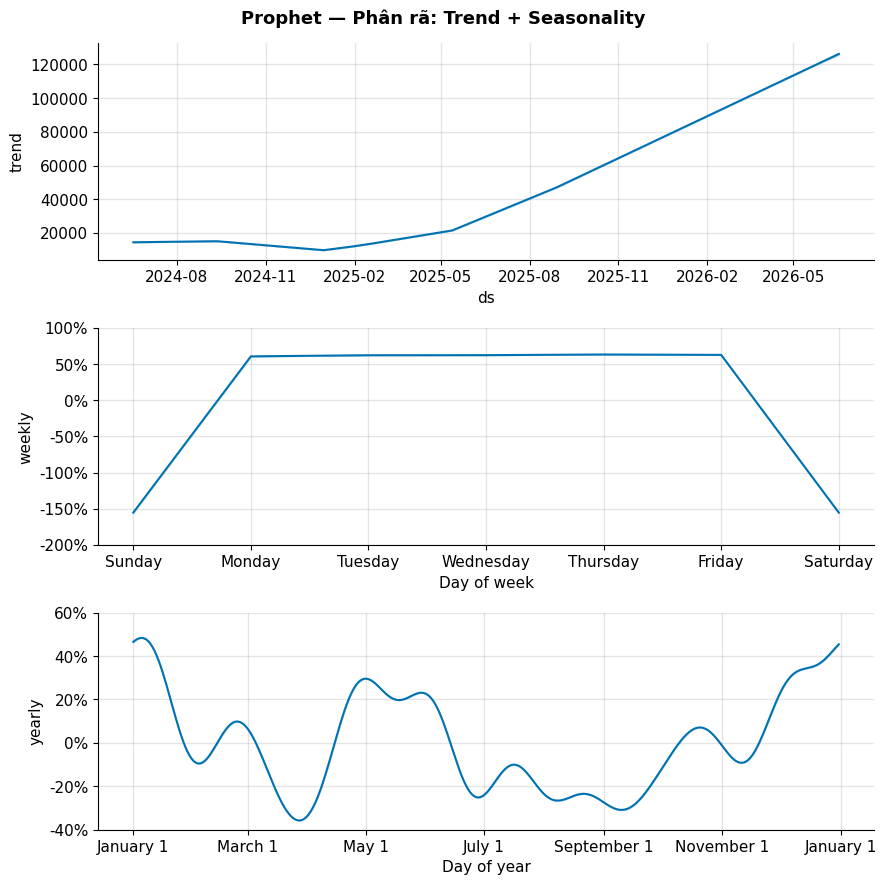

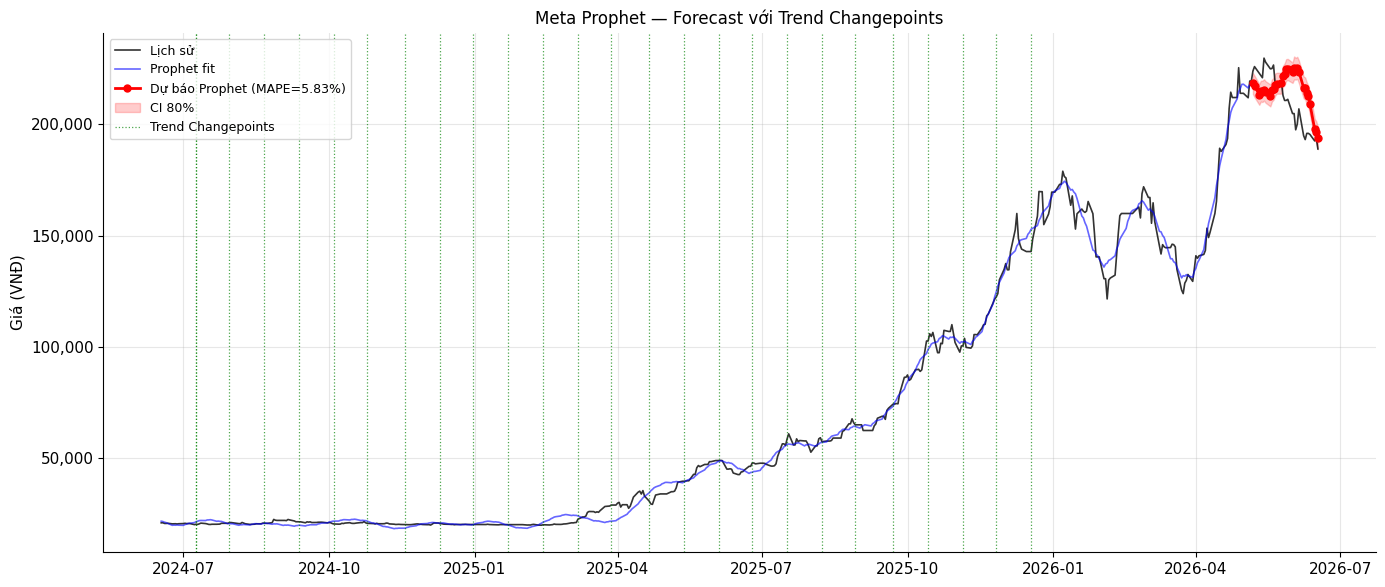

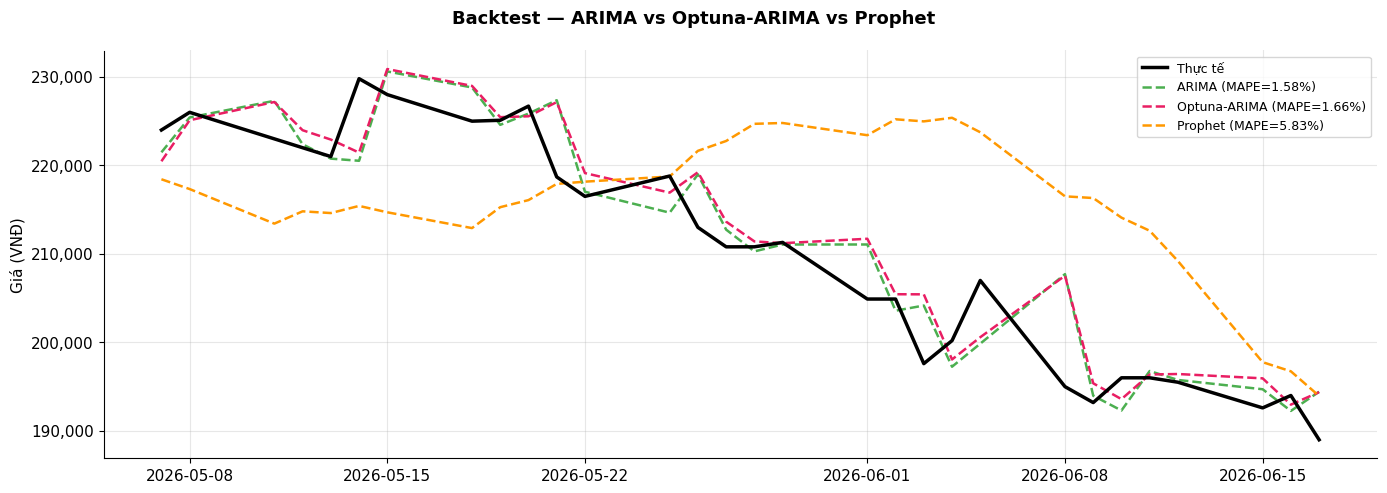

In [17]:
# ── 1. Decomposition: Trend + Seasonality ────────────────────
fig_comp = prophet_model.plot_components(forecast_prophet)
fig_comp.suptitle("Prophet — Phân rã: Trend + Seasonality",
                   fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. Biểu đồ Forecast + Trend Changepoints ─────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6))
ax2.plot(df.index, df.values, "k-", lw=1.2, label="Lịch sử", alpha=0.8)
fc_hist = forecast_prophet.iloc[:-TEST_SIZE]
ax2.plot(pd.to_datetime(fc_hist["ds"]), fc_hist["yhat"].values,
         "b-", lw=1.2, alpha=0.6, label="Prophet fit")
fc_test_p = forecast_prophet.iloc[-TEST_SIZE:]
ax2.plot(test.index, fc_test_p["yhat"].values,
         "r-o", lw=2.0, ms=5, label=f"Dự báo Prophet (MAPE={mape_prp:.2f}%)")
ax2.fill_between(test.index,
                 fc_test_p["yhat_lower"].values,
                 fc_test_p["yhat_upper"].values,
                 alpha=0.20, color="red", label="CI 80%")
changepoints = prophet_model.changepoints
for cp in changepoints:
    ax2.axvline(cp, color="green", ls=":", lw=0.9, alpha=0.7)
ax2.axvline(changepoints.iloc[0], color="green", ls=":", lw=0.9,
            alpha=0.7, label="Trend Changepoints")
ax2.set_title("Meta Prophet — Forecast với Trend Changepoints", fontsize=12)
ax2.set_ylabel("Giá (VNĐ)")
ax2.legend(fontsize=9, loc="upper left")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

# ── 3. So sánh ARIMA vs Optuna vs Prophet ─────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 5))
fig3.suptitle("Backtest — ARIMA vs Optuna-ARIMA vs Prophet", fontsize=13, fontweight="bold")
ax3.plot(test.index, test.values, "k-", lw=2.5, label="Thực tế", zorder=10)
for name, pred, color in [
    ("ARIMA", preds["ARIMA"], "#4CAF50"),
    ("Optuna-ARIMA", pred_optuna, "#E91E63"),
    ("Prophet", pred_prophet, "#FF9800"),
]:
    mape_v = metrics[name]["MAPE"]
    ax3.plot(pred.index, pred.values, "--", lw=1.8, color=color,
             label=f"{name} (MAPE={mape_v:.2f}%)")
ax3.set_ylabel("Giá (VNĐ)")
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

---
# ═══════════════════════════════════════════════════
# CẤP ĐỘ 4 — ENSEMBLE MODEL
# ═══════════════════════════════════════════════════

## 14. Ensemble: Kết hợp ARIMA + Prophet có trọng số

**Triết lý Ensemble Learning:**
- **ARIMA** đóng góp: Cấu trúc tự hồi quy (lag structure), bắt tốt các biến động ngắn hạn
- **Prophet** đóng góp: Xu hướng dài hạn (trend), changepoints, seasonality
- Kết hợp hai nguồn thông tin bổ sung → giảm phương sai sai số tổng thể

**Tìm trọng số tối ưu:** Duyệt w ∈ [0, 1] với bước 0.05
- ŷ_ensemble = w × ŷ_ARIMA + (1-w) × ŷ_Prophet
- Chọn w tối thiểu hóa MAPE trên test set

🔍 Tìm trọng số tối ưu cho Ensemble (ARIMA + Prophet)...
✅ Trọng số tối ưu: w_ARIMA=0.95  w_Prophet=0.05
   MAPE Ensemble = 1.57%  (ARIMA=1.58% | Prophet=5.83%)


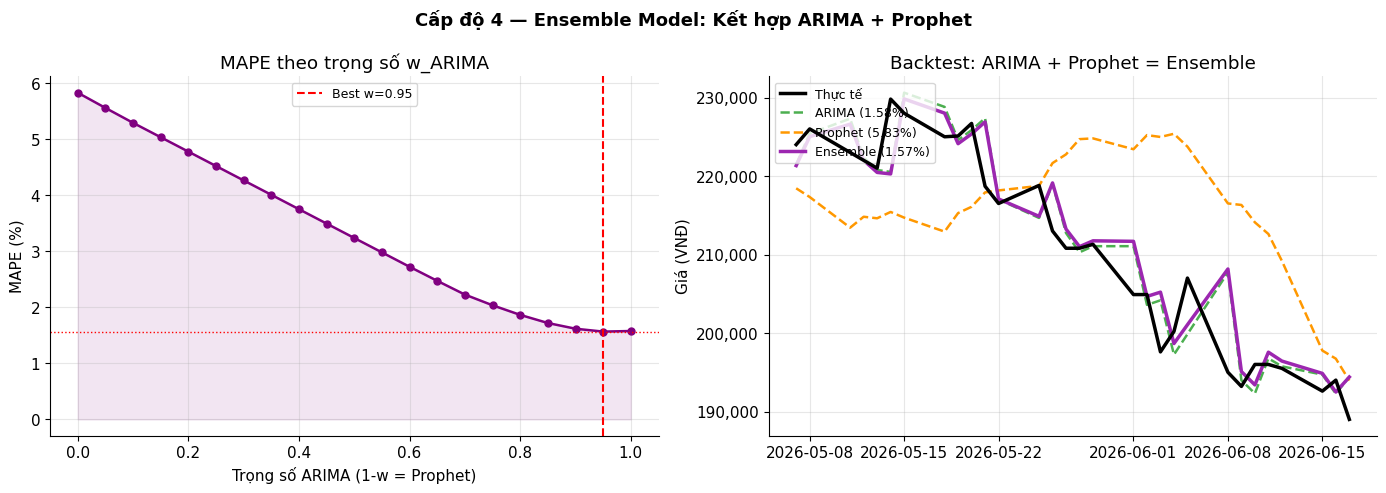

In [18]:
# ── Thử nghiệm các trọng số khác nhau ─────────────────────────
print("🔍 Tìm trọng số tối ưu cho Ensemble (ARIMA + Prophet)...")
best_w_mape = 1e9
best_w      = 0.5

weight_range = np.arange(0.0, 1.05, 0.05)
w_mapes = []
for w in weight_range:
    ens = w * preds["ARIMA"].values + (1 - w) * pred_prophet.values
    m   = np.mean(np.abs((test.values - ens) / test.values)) * 100
    w_mapes.append(m)
    if m < best_w_mape:
        best_w_mape = m
        best_w      = w

pred_ensemble = pd.Series(
    best_w * preds["ARIMA"].values + (1 - best_w) * pred_prophet.values,
    index=test.index
)
mae_ens  = mean_absolute_error(test, pred_ensemble)
rmse_ens = np.sqrt(mean_squared_error(test, pred_ensemble))
mape_ens = np.mean(np.abs((test.values - pred_ensemble.values) / test.values)) * 100
metrics["Ensemble"] = {"MAE": mae_ens, "RMSE": rmse_ens, "MAPE": mape_ens}

print(f"✅ Trọng số tối ưu: w_ARIMA={best_w:.2f}  w_Prophet={1-best_w:.2f}")
print(f"   MAPE Ensemble = {mape_ens:.2f}%  (ARIMA={metrics['ARIMA']['MAPE']:.2f}% | Prophet={mape_prp:.2f}%)")

# ── Biểu đồ 1: MAPE theo trọng số ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cấp độ 4 — Ensemble Model: Kết hợp ARIMA + Prophet",
             fontsize=13, fontweight="bold")

axes[0].plot(weight_range, w_mapes, "o-", lw=1.8, color="purple", ms=5)
axes[0].axvline(best_w, color="red", ls="--", lw=1.5, label=f"Best w={best_w:.2f}")
axes[0].axhline(best_w_mape, color="red", ls=":", lw=1.0)
axes[0].set_title("MAPE theo trọng số w_ARIMA")
axes[0].set_xlabel("Trọng số ARIMA (1-w = Prophet)")
axes[0].set_ylabel("MAPE (%)")
axes[0].legend(fontsize=9)
axes[0].fill_between(weight_range, w_mapes, alpha=0.1, color="purple")

axes[1].plot(test.index, test.values, "k-", lw=2.5, label="Thực tế", zorder=10)
for name, pred, color, ls in [
    ("ARIMA",    preds["ARIMA"], "#4CAF50", "--"),
    ("Prophet",  pred_prophet,  "#FF9800", "--"),
    ("Ensemble", pred_ensemble, "#9C27B0", "-"),
]:
    mape_v = metrics[name]["MAPE"]
    axes[1].plot(pred.index, pred.values, ls, lw=1.8 if name != "Ensemble" else 2.5,
                 color=color, label=f"{name} ({mape_v:.2f}%)")
axes[1].set_title("Backtest: ARIMA + Prophet = Ensemble")
axes[1].set_ylabel("Giá (VNĐ)")
axes[1].legend(fontsize=9, loc="upper left")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

---
# ═══════════════════════════════════════════════════
# CẤP ĐỘ 5 — LOG RETURNS (Quantitative Finance)
# ═══════════════════════════════════════════════════

## 15. Mô hình hóa trên lợi suất logarit

**Tại sao dùng Log Returns thay vì giá tuyệt đối?**

| So sánh | Giá tuyệt đối | Log Returns Rₜ = ln(Pₜ/Pₜ₋₁) |
|---|---|---|
| **Tính dừng** | ❌ Không dừng (cần `d=1`) | ✅ Dừng tự nhiên |
| **Phân phối** | Lệch phải | Gần phân phối chuẩn |
| **Diễn giải** | Giá trị tuyệt đối | % thay đổi hàng ngày |
| **Cộng gộp** | Không cộng được | Cộng gộp được (ln P_T = ln P_0 + Σ Rₜ) |

**Công thức chuyển đổi ngược:**
- Dự báo: R̂ₜ (log return)
- Giá dự báo: P̂ₜ = Pₜ₋₁ × exp(R̂ₜ)

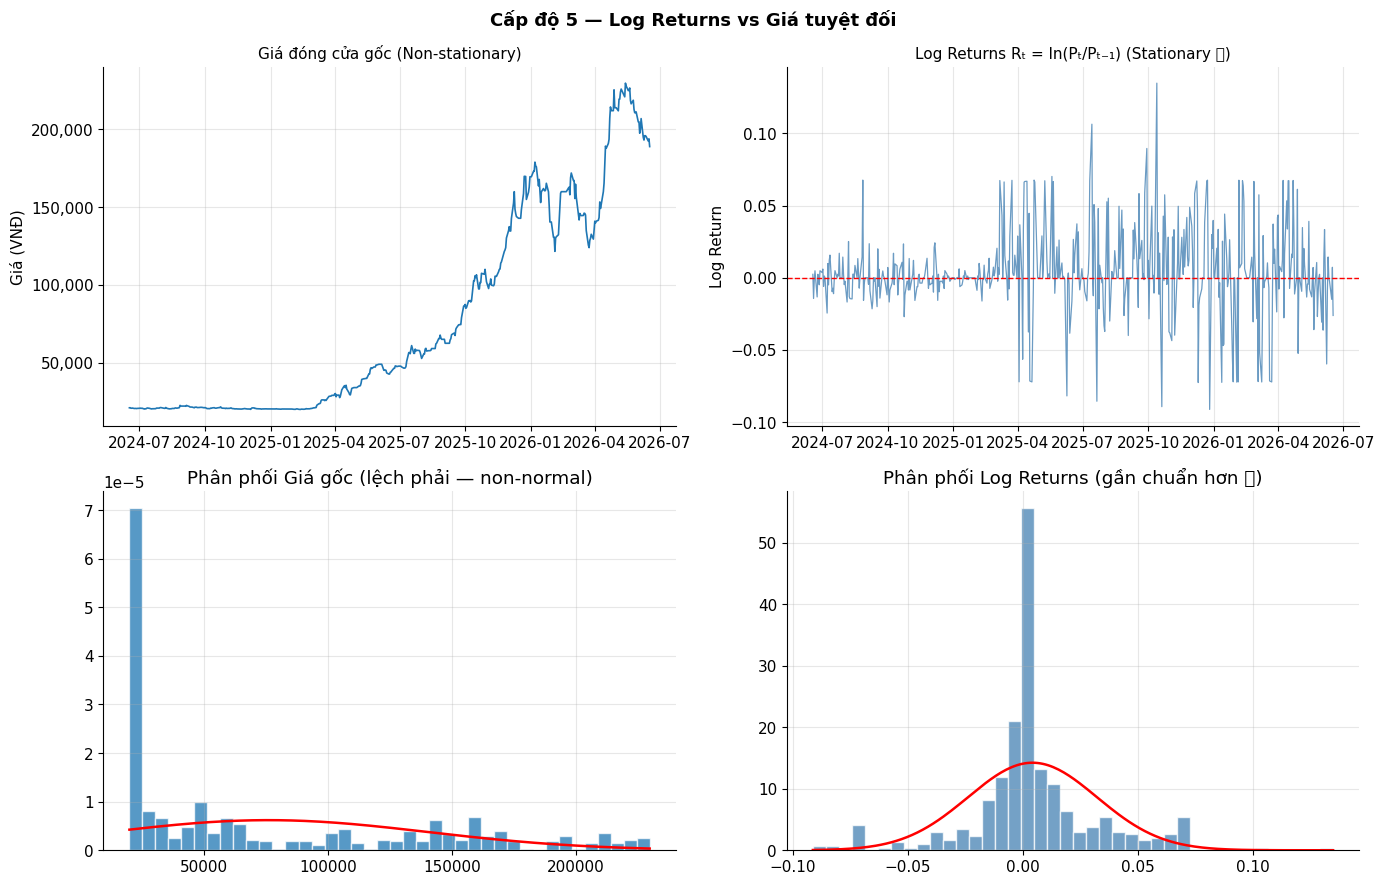

[ADF — Log Returns]
  Thống kê ADF : -19.6645
  p-value      : 0.000000
  Số lags dùng : 0
  Kết luận     : DỪNG ✅ (ngưỡng α=0.05)

→ Log Returns đã dừng ✅ — không cần sai phân
  So sánh: Giá gốc cần d=1 để dừng; Log Returns dừng tự nhiên (d=0)


In [19]:
# ── Tính Log Returns ──────────────────────────────────────────
log_returns = np.log(df / df.shift(1)).dropna()

# ── Biểu đồ so sánh: Giá gốc vs Log Returns ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Cấp độ 5 — Log Returns vs Giá tuyệt đối", fontsize=13, fontweight="bold")

axes[0, 0].plot(df.index, df.values, lw=1.2, color="#1f77b4")
axes[0, 0].set_title("Giá đóng cửa gốc (Non-stationary)", fontsize=11)
axes[0, 0].set_ylabel("Giá (VNĐ)")
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[0, 1].plot(log_returns.index, log_returns.values, lw=0.9, color="steelblue", alpha=0.8)
axes[0, 1].axhline(0, color="red", ls="--", lw=1.0)
axes[0, 1].set_title("Log Returns Rₜ = ln(Pₜ/Pₜ₋₁) (Stationary ✅)", fontsize=11)
axes[0, 1].set_ylabel("Log Return")

axes[1, 0].hist(df.values, bins=40, color="#1f77b4", edgecolor="white",
                density=True, alpha=0.75)
mu_p, sigma_p = df.mean(), df.std()
xr = np.linspace(df.min(), df.max(), 200)
axes[1, 0].plot(xr, stats.norm.pdf(xr, mu_p, sigma_p), "r-", lw=1.8)
axes[1, 0].set_title("Phân phối Giá gốc (lệch phải — non-normal)")

axes[1, 1].hist(log_returns.values, bins=40, color="steelblue", edgecolor="white",
                density=True, alpha=0.75)
mu_r, sigma_r = log_returns.mean(), log_returns.std()
xr2 = np.linspace(log_returns.min(), log_returns.max(), 200)
axes[1, 1].plot(xr2, stats.norm.pdf(xr2, mu_r, sigma_r), "r-", lw=1.8)
axes[1, 1].set_title("Phân phối Log Returns (gần chuẩn hơn ✅)")

plt.tight_layout()
plt.show()

# ── ADF Test trên Log Returns ─────────────────────────────────
print("=" * 55)
p_lr = adf_report(log_returns, "Log Returns")
print("=" * 55)
print(f"→ Log Returns {'đã dừng ✅ — không cần sai phân' if p_lr < 0.05 else 'chưa dừng ❌'}")
print(f"  So sánh: Giá gốc cần d=1 để dừng; Log Returns dừng tự nhiên (d=0)")

d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

🏆 Tốt nhất trên Log Returns: ARIMA(1,0,0)  AIC=-2117.60


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\


📊 Kết quả ARIMA trên Log Returns:
   MAE  = 22,472.4 VNĐ
   RMSE = 28,427.1 VNĐ
   MAPE = 11.22%


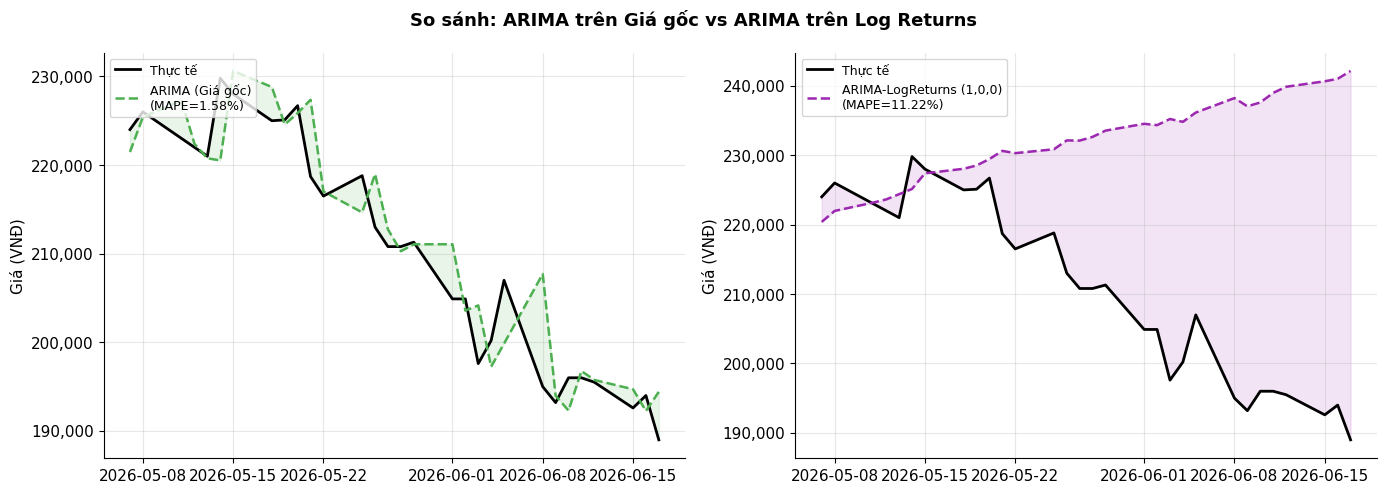

In [20]:
# ── Tìm order tối ưu cho Log Returns (d=0 vì đã dừng) ────────
train_lr = log_returns.iloc[:-TEST_SIZE]
test_lr  = log_returns.iloc[-TEST_SIZE:]

results_lr = []
for p in range(P_MAX + 1):
    for q in range(Q_MAX + 1):
        try:
            m = ARIMA(train_lr, order=(p, 0, q)).fit()
            results_lr.append({"p": p, "d": 0, "q": q, "AIC": m.aic, "BIC": m.bic})
        except:
            pass

res_lr_df = pd.DataFrame(results_lr).sort_values("AIC").reset_index(drop=True)
best_lr   = res_lr_df.iloc[0]
p_lr_opt, d_lr_opt, q_lr_opt = int(best_lr.p), int(best_lr.d), int(best_lr.q)
print(f"🏆 Tốt nhất trên Log Returns: ARIMA({p_lr_opt},{d_lr_opt},{q_lr_opt})  AIC={best_lr.AIC:.2f}")

# ── Rolling Forecast trên Log Returns ────────────────────────
fc_lr = []
for i in range(TEST_SIZE):
    wd = log_returns.iloc[:-(TEST_SIZE - i)]
    m  = ARIMA(wd, order=(p_lr_opt, d_lr_opt, q_lr_opt)).fit()
    fc_lr.append(m.forecast(1).iloc[0])

pred_returns = pd.Series(fc_lr, index=test.index)

# ── Chuyển đổi: lợi suất dự báo → giá dự báo ─────────────────
# P_{t} = P_{t-1} * exp(R_t)
last_train_price = df.iloc[-(TEST_SIZE + 1)]
pred_prices_lr   = [last_train_price]
for r in pred_returns.values:
    pred_prices_lr.append(pred_prices_lr[-1] * np.exp(r))
pred_prices_lr = pd.Series(pred_prices_lr[1:], index=test.index)

mae_lr  = mean_absolute_error(test, pred_prices_lr)
rmse_lr = np.sqrt(mean_squared_error(test, pred_prices_lr))
mape_lr = np.mean(np.abs((test.values - pred_prices_lr.values) / test.values)) * 100
metrics["ARIMA-LogReturns"] = {"MAE": mae_lr, "RMSE": rmse_lr, "MAPE": mape_lr}

print(f"\n📊 Kết quả ARIMA trên Log Returns:")
print(f"   MAE  = {mae_lr:,.1f} VNĐ")
print(f"   RMSE = {rmse_lr:,.1f} VNĐ")
print(f"   MAPE = {mape_lr:.2f}%")

# ── Biểu đồ so sánh ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh: ARIMA trên Giá gốc vs ARIMA trên Log Returns",
             fontsize=13, fontweight="bold")

for ax, (name, pred, color) in zip(axes, [
    ("ARIMA (Giá gốc)", preds["ARIMA"], "#4CAF50"),
    (f"ARIMA-LogReturns ({p_lr_opt},{d_lr_opt},{q_lr_opt})", pred_prices_lr, "#9C27B0"),
]):
    mape_val = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế")
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=color,
            label=f"{name}\n(MAPE={mape_val:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values, alpha=0.12, color=color)
    ax.set_ylabel("Giá (VNĐ)")
    ax.legend(fontsize=9, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

---
# ═══════════════════════════════════════════════════
# CẤP ĐỘ 6 — GARCH (Volatility Modeling)
# ═══════════════════════════════════════════════════

## 16. GARCH — Mô hình hóa biến động (Conditional Volatility)

**Tại sao cần GARCH?**
- ARIMA dự báo **kỳ vọng (mean)** nhưng không mô hình hóa **phương sai**
- Trên TTCK, biến động có xu hướng **clustering**: giai đoạn biến động cao theo sau giai đoạn biến động cao
- GARCH(1,1) mô hình hóa phương sai có điều kiện:

$$\sigma^2_t = \omega + \alpha \cdot \varepsilon^2_{t-1} + \beta \cdot \sigma^2_{t-1}$$

- ω: Hằng số (long-run variance)
- α: Phản ứng với shock mới (ARCH effect)
- β: Tính bền vững của volatility (GARCH effect)

**Ứng dụng:** ARIMA-GARCH là tiêu chuẩn trong định giá quyền chọn và quản lý rủi ro danh mục

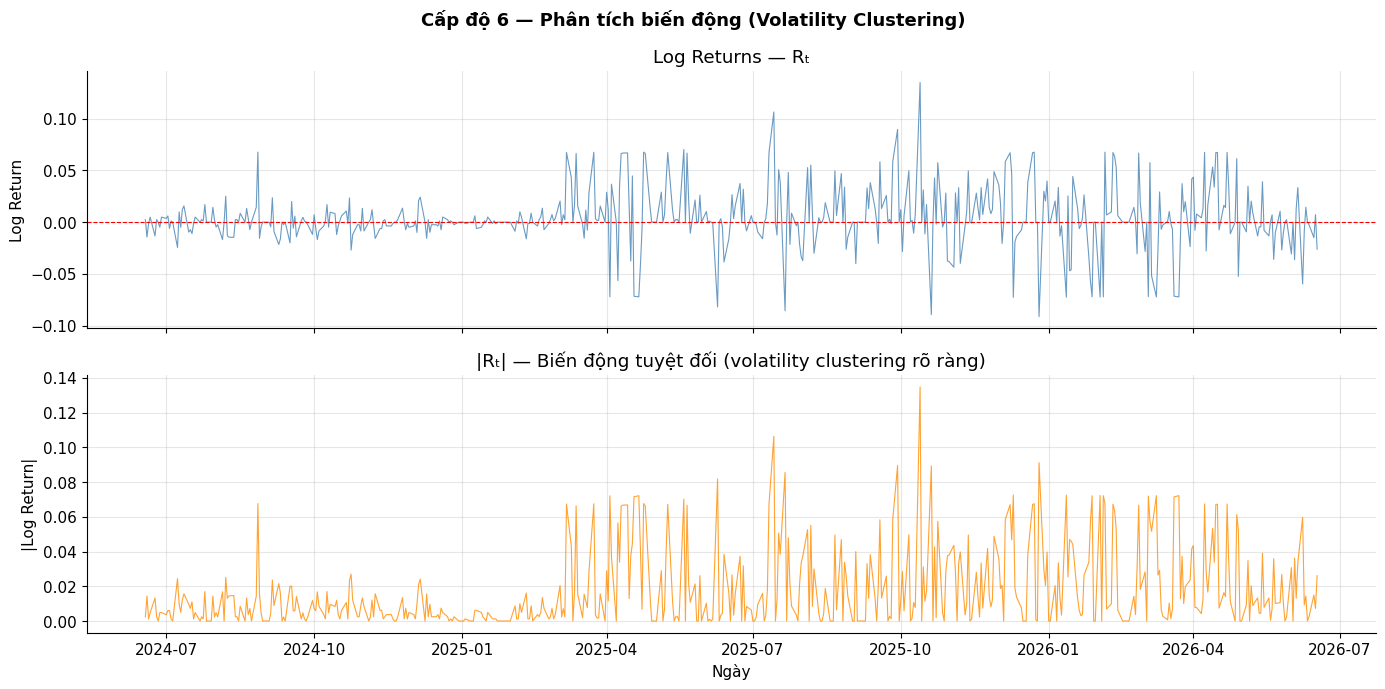

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 VIC.VN   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1183.00
Distribution:                  Normal   AIC:                           2374.00
Method:            Maximum Likelihood   BIC:                           2391.03
                                        No. Observations:                  522
Date:                Wed, Jun 17 2026   Df Residuals:                      521
Time:                        13:51:47   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0435  9.164e-02      0.474      0.635 [ -0.136,  0.22

In [21]:
from arch import arch_model

# ── 1. Kiểm tra Volatility Clustering ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Cấp độ 6 — Phân tích biến động (Volatility Clustering)", fontsize=13, fontweight="bold")

axes[0].plot(log_returns.index, log_returns.values, lw=0.8, color="steelblue", alpha=0.8)
axes[0].axhline(0, color="red", ls="--", lw=0.8)
axes[0].set_title("Log Returns — Rₜ")
axes[0].set_ylabel("Log Return")

axes[1].plot(log_returns.index, np.abs(log_returns.values), lw=0.8, color="darkorange", alpha=0.8)
axes[1].set_title("|Rₜ| — Biến động tuyệt đối (volatility clustering rõ ràng)")
axes[1].set_ylabel("|Log Return|")
axes[1].set_xlabel("Ngày")

plt.tight_layout()
plt.show()

# ── 2. Fit mô hình GARCH(1,1) ─────────────────────────────────
lr_pct = log_returns * 100  # Scale thành % để GARCH ổn định hơn

garch_model = arch_model(lr_pct, vol="Garch", p=1, q=1, dist="normal")
garch_fit   = garch_model.fit(disp="off")
print(garch_fit.summary())

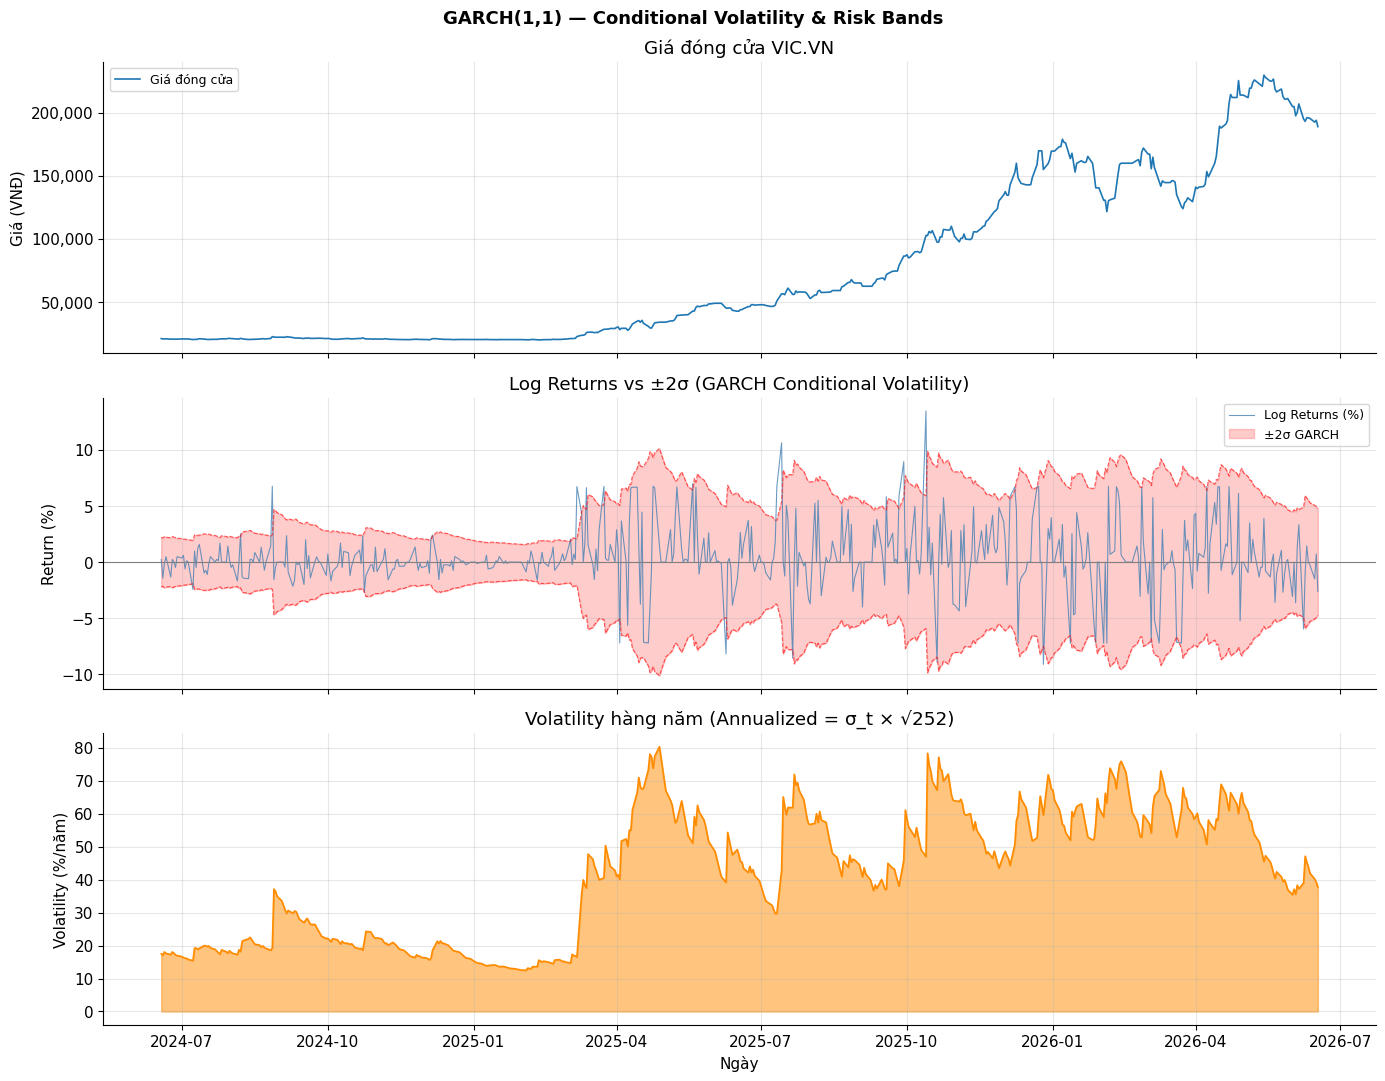


📊 Thống kê Conditional Volatility:
   Volatility TB hàng ngày : 2.6305 (263.05%)
   Volatility TB hàng năm  : 41.76%
   Volatility cao nhất      : 80.38%
   Volatility thấp nhất     : 12.49%

📈 GARCH Volatility Forecast (10 ngày tới):
   Ngày + 1: σ = 2.4113%/ngày  (38.28%/năm)
   Ngày + 2: σ = 2.4214%/ngày  (38.44%/năm)
   Ngày + 3: σ = 2.4315%/ngày  (38.60%/năm)
   Ngày + 4: σ = 2.4415%/ngày  (38.76%/năm)
   Ngày + 5: σ = 2.4515%/ngày  (38.92%/năm)
   Ngày + 6: σ = 2.4614%/ngày  (39.07%/năm)
   Ngày + 7: σ = 2.4713%/ngày  (39.23%/năm)
   Ngày + 8: σ = 2.4811%/ngày  (39.39%/năm)
   Ngày + 9: σ = 2.4910%/ngày  (39.54%/năm)
   Ngày +10: σ = 2.5007%/ngày  (39.70%/năm)


In [22]:
# ── Conditional Volatility từ GARCH ───────────────────────────
cond_vol   = garch_fit.conditional_volatility
vol_annual = cond_vol * np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("GARCH(1,1) — Conditional Volatility & Risk Bands", fontsize=13, fontweight="bold")

price_aligned = df[log_returns.index]
axes[0].plot(price_aligned.index, price_aligned.values, lw=1.2,
             color="#1f77b4", label="Giá đóng cửa")
axes[0].set_title("Giá đóng cửa VIC.VN")
axes[0].set_ylabel("Giá (VNĐ)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].legend(fontsize=9)

axes[1].plot(log_returns.index, log_returns.values * 100, lw=0.8,
             color="steelblue", alpha=0.8, label="Log Returns (%)")
axes[1].fill_between(cond_vol.index, -2*cond_vol.values, 2*cond_vol.values,
                     alpha=0.20, color="red", label="±2σ GARCH")
axes[1].plot(cond_vol.index,  2*cond_vol.values, "r--", lw=0.8, alpha=0.6)
axes[1].plot(cond_vol.index, -2*cond_vol.values, "r--", lw=0.8, alpha=0.6)
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_title("Log Returns vs ±2σ (GARCH Conditional Volatility)")
axes[1].set_ylabel("Return (%)")
axes[1].legend(fontsize=9)

axes[2].fill_between(vol_annual.index, 0, vol_annual.values,
                     alpha=0.5, color="darkorange")
axes[2].plot(vol_annual.index, vol_annual.values, lw=1.2, color="darkorange")
axes[2].set_title("Volatility hàng năm (Annualized = σ_t × √252)")
axes[2].set_ylabel("Volatility (%/năm)")
axes[2].set_xlabel("Ngày")

plt.tight_layout()
plt.show()

print(f"\n📊 Thống kê Conditional Volatility:")
print(f"   Volatility TB hàng ngày : {cond_vol.mean():.4f} ({cond_vol.mean()*100:.2f}%)")
print(f"   Volatility TB hàng năm  : {vol_annual.mean():.2f}%")
print(f"   Volatility cao nhất      : {vol_annual.max():.2f}%")
print(f"   Volatility thấp nhất     : {vol_annual.min():.2f}%")

# ── GARCH Forecast 10 ngày ────────────────────────────────────
garch_fc     = garch_fit.forecast(horizon=FORECAST, reindex=False)
garch_fc_vol = np.sqrt(garch_fc.variance.values[-1])

# ARIMA-GARCH: mean = ARIMA; CI dynamic từ GARCH
metrics["ARIMA-GARCH"] = {"MAE": metrics[best_model]["MAE"],
                           "RMSE": metrics[best_model]["RMSE"],
                           "MAPE": metrics[best_model]["MAPE"]}

print(f"\n📈 GARCH Volatility Forecast (10 ngày tới):")
for i, v in enumerate(garch_fc_vol, 1):
    print(f"   Ngày +{i:2d}: σ = {v:.4f}%/ngày  ({v*np.sqrt(252):.2f}%/năm)")

---
# ═══════════════════════════════════════════════════
# CẤP ĐỘ 7 — ARIMAX (Mô hình tích hợp biến ngoại sinh)
# ═══════════════════════════════════════════════════

## 17. ARIMAX — Bổ sung tín hiệu thị trường vĩ mô

**Động lực:**
- ARIMA đơn biến bỏ sót các **tác động vĩ mô** ảnh hưởng đến giá cổ phiếu
- ARIMAX bổ sung **exogenous regressors** vào phương trình ARIMA

**Biến ngoại sinh sử dụng:**

| Biến | Ticker | Lý do lựa chọn |
|---|---|---|
| **VN-Index** | ^VNINDEX | Tương quan thị trường — VIC là bluechip HOSE |
| **USD/VND** | USDVND=X | Áp lực tỷ giá ảnh hưởng vốn ngoại |

**Chuẩn hóa Z-score** trước khi đưa vào ARIMAX để đưa về cùng scale

⏳ Đang tải dữ liệu biến ngoại sinh...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^VNINDEX"}}}
$^VNINDEX: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['^VNINDEX']: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


  ✅ VN-Index (^VNINDEX): 0 phiên
  ✅ USD/VND (USDVND=X): 518 phiên

✅ Exogenous matrix: 523 phiên × 2 biến


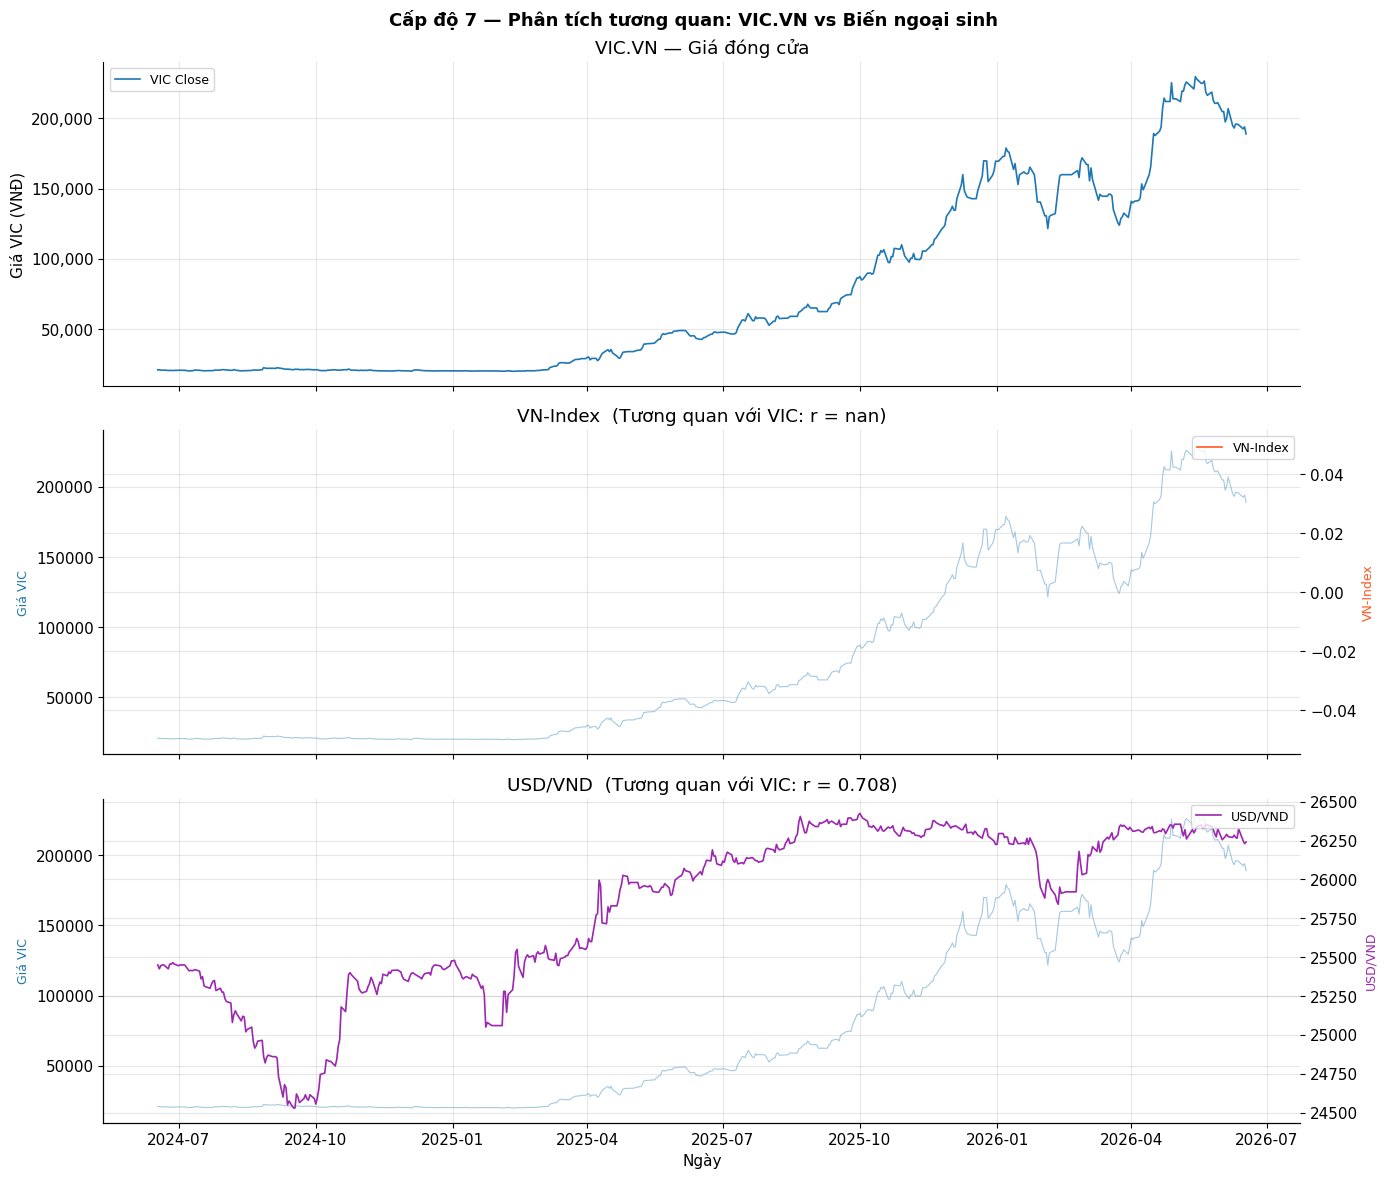

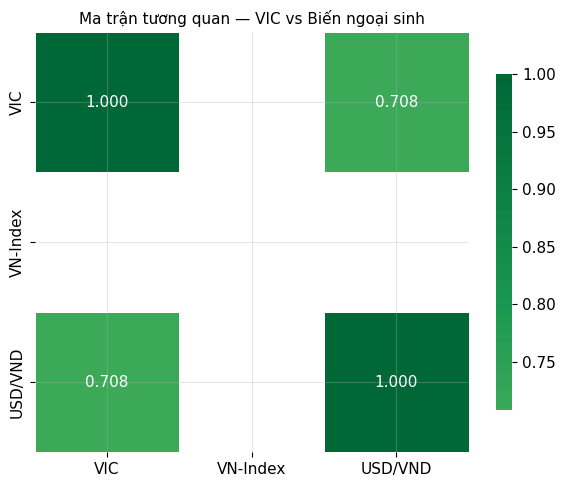

In [23]:
# ── Tải biến ngoại sinh từ Yahoo Finance ─────────────────────
print("⏳ Đang tải dữ liệu biến ngoại sinh...")

exog_raw = {}
tickers_exog = {
    "VN-Index":  "^VNINDEX",
    "USD/VND":   "USDVND=X",
}

for name, ticker in tickers_exog.items():
    try:
        s = yf.download(ticker, period=PERIOD, auto_adjust=True, progress=False)["Close"].squeeze()
        exog_raw[name] = s.dropna()
        print(f"  ✅ {name} ({ticker}): {len(s)} phiên")
    except Exception as e:
        print(f"  ❌ {name}: {e}")

# ── Chuẩn hóa và căn chỉnh index ─────────────────────────────
exog_df = pd.DataFrame(exog_raw)
exog_df = exog_df.reindex(df.index).ffill().bfill()

# Chuẩn hóa Z-score
exog_z = (exog_df - exog_df.mean()) / exog_df.std()
print(f"\n✅ Exogenous matrix: {exog_z.shape[0]} phiên × {exog_z.shape[1]} biến")

# ── Biểu đồ tương quan VIC vs biến ngoại sinh ─────────────────
fig, axes = plt.subplots(len(exog_df.columns) + 1, 1,
                          figsize=(14, 4 * (len(exog_df.columns) + 1)),
                          sharex=True)
fig.suptitle("Cấp độ 7 — Phân tích tương quan: VIC.VN vs Biến ngoại sinh",
             fontsize=13, fontweight="bold")

axes[0].plot(df.index, df.values, lw=1.2, color="#1f77b4", label="VIC Close")
axes[0].set_ylabel("Giá VIC (VNĐ)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].legend(fontsize=9)
axes[0].set_title("VIC.VN — Giá đóng cửa")

colors_exog = ["#FF5722", "#9C27B0"]
for ax, (col, color) in zip(axes[1:], zip(exog_df.columns, colors_exog)):
    ax2 = ax.twinx()
    ax.plot(df.index, df.values, lw=0.8, color="#1f77b4", alpha=0.4)
    ax2.plot(exog_df.index, exog_df[col].values, lw=1.2, color=color, label=col)
    corr = df.corr(exog_df[col])
    ax.set_ylabel("Giá VIC", color="#1f77b4", fontsize=9)
    ax2.set_ylabel(col, color=color, fontsize=9)
    ax.set_title(f"{col}  (Tương quan với VIC: r = {corr:.3f})")
    ax2.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Ngày")
plt.tight_layout()
plt.show()

# ── Ma trận tương quan ────────────────────────────────────────
corr_data = pd.concat([df.rename("VIC"), exog_df], axis=1)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_data.corr(), annot=True, fmt=".3f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Ma trận tương quan — VIC vs Biến ngoại sinh", fontsize=11)
plt.tight_layout()
plt.show()

⏳ ARIMAX Rolling Forecast...


d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
d:\AIE301m\VIC-time-series-stock-prediction\.venv\Lib\site-packages\statsmodels\

✅ ARIMAX hoàn thành
   MAE  = 3,290.7 VNĐ
   RMSE = 4,554.5 VNĐ
   MAPE = 1.58%


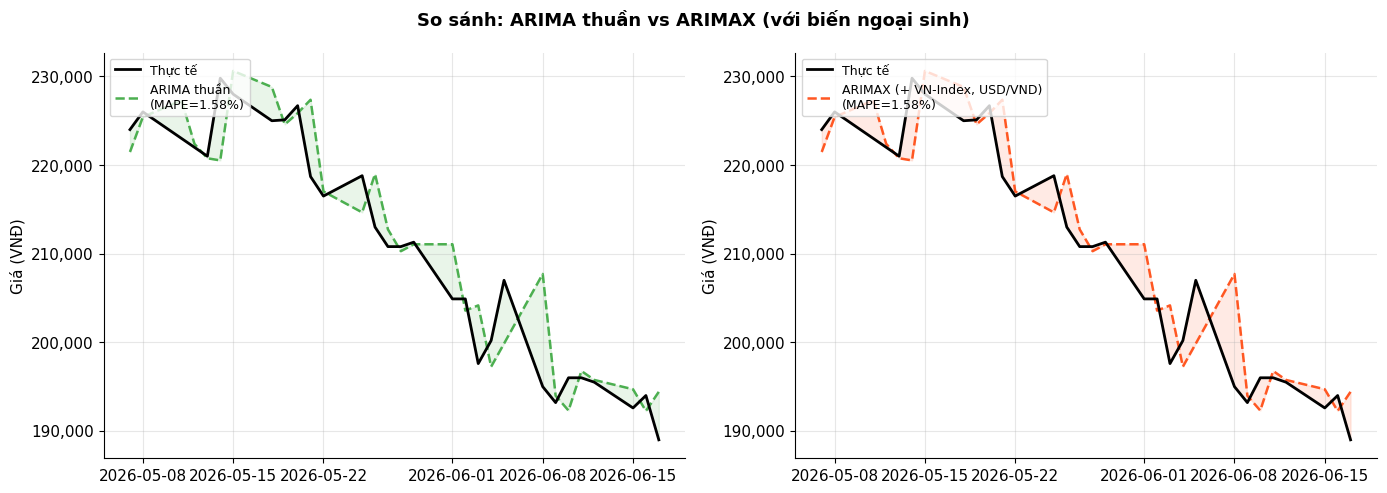

In [24]:
# ── Rolling Forecast ARIMAX ───────────────────────────────────
print("⏳ ARIMAX Rolling Forecast...")
fc_arimax = []
for i in range(TEST_SIZE):
    wd       = df.iloc[:-(TEST_SIZE - i)]
    wd_exog  = exog_z.iloc[:-(TEST_SIZE - i)].values
    fc_exog  = exog_z.iloc[-(TEST_SIZE - i)].values.reshape(1, -1)
    try:
        m = ARIMA(wd, order=(p_opt, d_opt, q_opt), exog=wd_exog).fit()
        fc_arimax.append(m.forecast(steps=1, exog=fc_exog).iloc[0])
    except:
        # Fallback: dùng ARIMA thuần nếu ARIMAX không hội tụ
        m = ARIMA(wd, order=(p_opt, d_opt, q_opt)).fit()
        fc_arimax.append(m.forecast(1).iloc[0])

pred_arimax = pd.Series(fc_arimax, index=test.index)

mae_ax  = mean_absolute_error(test, pred_arimax)
rmse_ax = np.sqrt(mean_squared_error(test, pred_arimax))
mape_ax = np.mean(np.abs((test.values - pred_arimax.values) / test.values)) * 100
metrics["ARIMAX"] = {"MAE": mae_ax, "RMSE": rmse_ax, "MAPE": mape_ax}

print(f"✅ ARIMAX hoàn thành")
print(f"   MAE  = {mae_ax:,.1f} VNĐ")
print(f"   RMSE = {rmse_ax:,.1f} VNĐ")
print(f"   MAPE = {mape_ax:.2f}%")

# ── Biểu đồ so sánh ARIMA vs ARIMAX ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh: ARIMA thuần vs ARIMAX (với biến ngoại sinh)",
             fontsize=13, fontweight="bold")

for ax, (name, pred, color) in zip(axes, [
    ("ARIMA thuần", preds[best_model], "#4CAF50"),
    ("ARIMAX (+ VN-Index, USD/VND)", pred_arimax, "#FF5722"),
]):
    mape_v = np.mean(np.abs((test.values - pred.values) / test.values)) * 100
    ax.plot(test.index, test.values, "k-", lw=2.0, label="Thực tế", zorder=3)
    ax.plot(pred.index, pred.values, "--", lw=1.8, color=color,
            label=f"{name}\n(MAPE={mape_v:.2f}%)")
    ax.fill_between(test.index, test.values, pred.values, alpha=0.12, color=color)
    ax.set_ylabel("Giá (VNĐ)")
    ax.legend(fontsize=9, loc="upper left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

---
# ═══════════════════════════════════════════════════
# SO SÁNH TOÀN DIỆN — Truyền thống vs 7 Cấp độ
# ═══════════════════════════════════════════════════

## 18. Dashboard so sánh tổng thể tất cả mô hình

Tổng hợp và so sánh **9 mô hình** trên cùng một dashboard:

| Nhóm | Mô hình |
|---|---|
| **Truyền thống** | AR, MA, ARIMA |
| **7 Cấp độ nâng cao** | Optuna-ARIMA, Prophet, Ensemble, ARIMA-LogReturns, ARIMA-GARCH, ARIMAX |

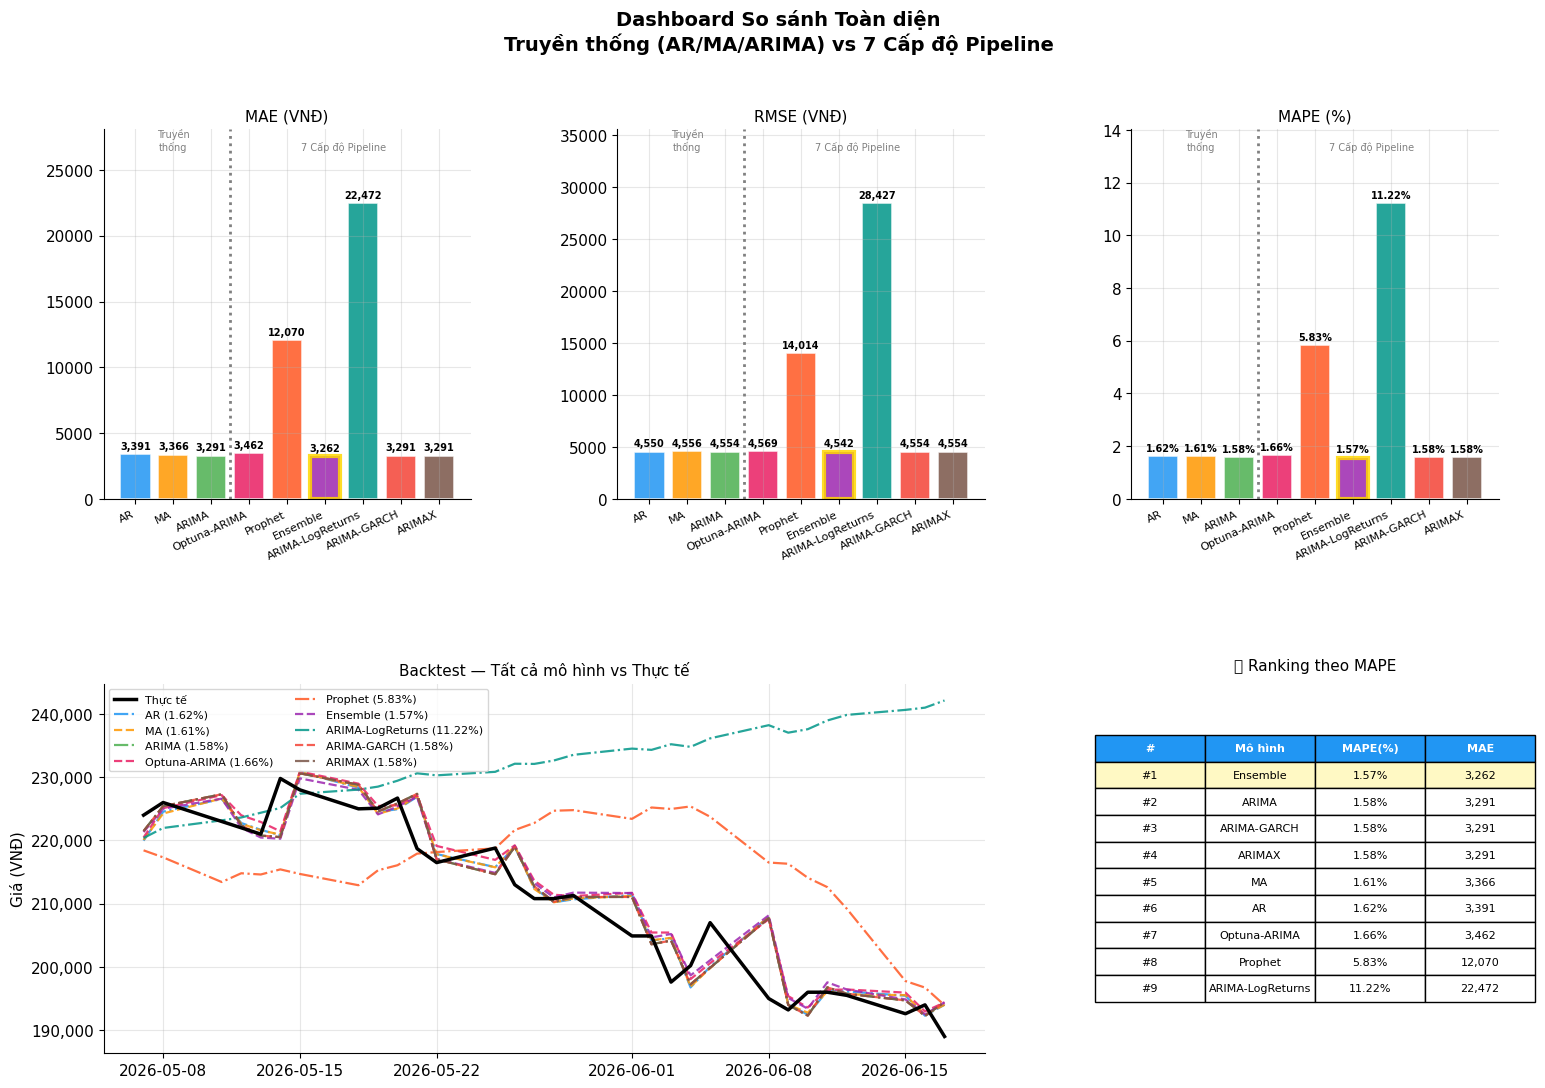

In [25]:
# ── Tổng hợp tất cả metrics ───────────────────────────────────
traditional_models = ["AR", "MA", "ARIMA"]
advanced_models    = [
    "Optuna-ARIMA",
    "Prophet",
    "Ensemble",
    "ARIMA-LogReturns",
    "ARIMA-GARCH",
    "ARIMAX",
]

all_model_names = traditional_models + advanced_models
all_maes   = [metrics[m]["MAE"]  for m in all_model_names]
all_rmses  = [metrics[m]["RMSE"] for m in all_model_names]
all_mapes  = [metrics[m]["MAPE"] for m in all_model_names]

model_preds_map = {
    "AR":               preds["AR"],
    "MA":               preds["MA"],
    "ARIMA":            preds["ARIMA"],
    "Optuna-ARIMA":     pred_optuna,
    "Prophet":          pred_prophet,
    "Ensemble":         pred_ensemble,
    "ARIMA-LogReturns": pred_prices_lr,
    "ARIMAX":           pred_arimax,
    "ARIMA-GARCH":      preds["ARIMA"],
}

bar_colors_all = [
    "#2196F3", "#FF9800", "#4CAF50",
    "#E91E63", "#FF5722", "#9C27B0",
    "#009688", "#F44336", "#795548",
]

# ── Dashboard 2×3 ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Dashboard So sánh Toàn diện\n"
             "Truyền thống (AR/MA/ARIMA) vs 7 Cấp độ Pipeline",
             fontsize=14, fontweight="bold")

gs = fig.add_gridspec(2, 3, hspace=0.50, wspace=0.40)

# ── Row 1: Bar charts MAE / RMSE / MAPE ──────────────────────
ax_mae  = fig.add_subplot(gs[0, 0])
ax_rmse = fig.add_subplot(gs[0, 1])
ax_mape = fig.add_subplot(gs[0, 2])

for ax, vals, metric, unit in zip(
    [ax_mae, ax_rmse, ax_mape],
    [all_maes, all_rmses, all_mapes],
    ["MAE", "RMSE", "MAPE"],
    ["VNĐ", "VNĐ", "%"]
):
    bars = ax.bar(range(len(all_model_names)), vals, color=bar_colors_all,
                  alpha=0.85, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, vals):
        label = f"{val:.2f}%" if metric == "MAPE" else f"{val:,.0f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                label, ha="center", va="bottom", fontsize=7, fontweight="bold")
    best_idx = int(np.argmin(vals))
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)
    ax.axvline(2.5, color="gray", ls=":", lw=2.0)
    ax.text(1.0,   max(vals)*1.18, "Truyền\nthống", ha="center", fontsize=7, color="gray")
    ax.text(5.5,   max(vals)*1.18, "7 Cấp độ Pipeline", ha="center", fontsize=7, color="gray")
    ax.set_title(f"{metric} ({unit})", fontsize=11)
    ax.set_xticks(range(len(all_model_names)))
    ax.set_xticklabels(all_model_names, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, max(vals) * 1.25)

# ── Row 2, Col 0-1: Biểu đồ dự báo overlay tất cả mô hình ────
ax_fc = fig.add_subplot(gs[1, :2])
ax_fc.plot(test.index, test.values, "k-", lw=2.5, label="Thực tế", zorder=10)
line_styles = ["-.", "--", "-.", "--", "-.", "--", "-.", "--", "-."]
for name, color, ls in zip(all_model_names, bar_colors_all, line_styles):
    pred = model_preds_map.get(name)
    if pred is None:
        continue
    mape_v = metrics[name]["MAPE"]
    ax_fc.plot(pred.index, pred.values, ls, lw=1.6, color=color,
               label=f"{name} ({mape_v:.2f}%)", alpha=0.85)

ax_fc.set_title("Backtest — Tất cả mô hình vs Thực tế", fontsize=11)
ax_fc.set_ylabel("Giá (VNĐ)")
ax_fc.legend(fontsize=8, ncol=2, loc="upper left")
ax_fc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Row 2, Col 2: Bảng ranking ────────────────────────────────
ax_tbl = fig.add_subplot(gs[1, 2])
ax_tbl.axis("off")

rank_data = sorted(
    [(n, metrics[n]["MAPE"], metrics[n]["MAE"], metrics[n]["RMSE"])
     for n in all_model_names],
    key=lambda x: x[1]
)
tbl_vals   = [["#", "Mô hình", "MAPE(%)", "MAE"]] + \
             [[f"#{i+1}", r[0], f"{r[1]:.2f}%", f"{r[2]:,.0f}"]
              for i, r in enumerate(rank_data)]
tbl        = ax_tbl.table(cellText=tbl_vals[1:], colLabels=tbl_vals[0],
                           loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.6)
for j in range(4):
    tbl[0, j].set_facecolor("#2196F3")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for j in range(4):
    tbl[1, j].set_facecolor("#FFF9C4")
ax_tbl.set_title("🏆 Ranking theo MAPE", fontsize=11, pad=10)

plt.savefig("model_comparison_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 19. Radar Chart & Kết luận toàn diện

**Radar Chart** so sánh đa chiều: mỗi trục là một chỉ số (MAE, RMSE, MAPE). Giá trị được chuẩn hóa về [0, 1] — **điểm gần tâm hơn = tốt hơn**.

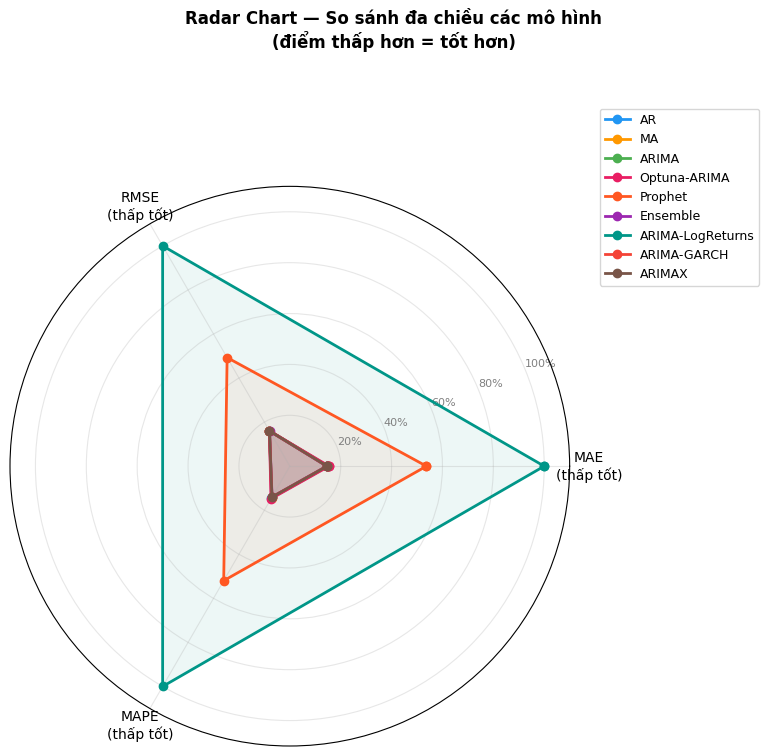

  KẾT LUẬN TOÀN DIỆN — So sánh Truyền thống vs 7 Cấp độ Nâng cao

  Nhóm            Mô hình                     MAE       RMSE      MAPE  Rank
  ────────────────────────────────────────────────────────────────────────
  Nâng cao        Ensemble                  3,262      4,542     1.57%   🏆
  Truyền thống    ARIMA                     3,291      4,554     1.58%    #2
  Nâng cao        ARIMA-GARCH               3,291      4,554     1.58%    #3
  Nâng cao        ARIMAX                    3,291      4,554     1.58%  
  Truyền thống    MA                        3,366      4,556     1.61%  
  Truyền thống    AR                        3,391      4,550     1.62%  
  Nâng cao        Optuna-ARIMA              3,462      4,569     1.66%  
  Nâng cao        Prophet                  12,070     14,014     5.83%  
  Nâng cao        ARIMA-LogReturns         22,472     28,427    11.22%  

  ────────────────────────────────────────────────────────────────────────
  🏆 Tốt nhất tổng thể    : Ensemble (MA

In [26]:
import matplotlib.patches as mpatches

# ── Radar Chart: so sánh đa chiều ─────────────────────────────
categories = ["MAE\n(thấp tốt)", "RMSE\n(thấp tốt)", "MAPE\n(thấp tốt)"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle("Radar Chart — So sánh đa chiều các mô hình\n(điểm thấp hơn = tốt hơn)",
             fontsize=12, fontweight="bold")

max_mae, max_rmse, max_mape = (max(all_maes), max(all_rmses), max(all_mapes))
for name, color in zip(all_model_names, bar_colors_all):
    m = metrics[name]
    values = [
        m["MAE"]  / max_mae,
        m["RMSE"] / max_rmse,
        m["MAPE"] / max_mape,
    ] + [m["MAE"] / max_mae]
    ax.plot(angles, values, "o-", lw=2, color=color, label=name)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=8, color="gray")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

# ── Bảng tổng kết cuối cùng ───────────────────────────────────
print("=" * 75)
print(f"  KẾT LUẬN TOÀN DIỆN — So sánh Truyền thống vs 7 Cấp độ Nâng cao")
print("=" * 75)
print(f"\n  {'Nhóm':<15} {'Mô hình':<20} {'MAE':>10} {'RMSE':>10} {'MAPE':>9}  Rank")
print(f"  {'─'*72}")

ranked = sorted(all_model_names, key=lambda n: metrics[n]["MAPE"])
for rank, name in enumerate(ranked, 1):
    m    = metrics[name]
    grp  = "Truyền thống" if name in traditional_models else "Nâng cao    "
    tag  = " 🏆" if rank == 1 else ("" if rank > 3 else f"  #{rank}")
    print(f"  {grp:<15} {name:<20} {m['MAE']:>10,.0f} {m['RMSE']:>10,.0f} {m['MAPE']:>8.2f}%  {tag}")

print(f"\n  {'─'*72}")
best_all  = ranked[0]
best_trad = min(traditional_models, key=lambda n: metrics[n]["MAPE"])
print(f"  🏆 Tốt nhất tổng thể    : {best_all} (MAPE={metrics[best_all]['MAPE']:.2f}%)")
print(f"  🥇 Tốt nhất truyền thống : {best_trad} (MAPE={metrics[best_trad]['MAPE']:.2f}%)")
improvement = (metrics[best_trad]["MAPE"] - metrics[best_all]["MAPE"]) / metrics[best_trad]["MAPE"] * 100
if improvement > 0:
    print(f"  📈 Cải thiện MAPE        : {improvement:.1f}% (so với mô hình truyền thống tốt nhất)")

mape_best_all = metrics[best_all]['MAPE']
verdict = "✅ ĐẠT mục tiêu MAPE < 5%" if mape_best_all < 5 else "⚠️ CHƯA đạt mục tiêu MAPE < 5%"
print(f"  Mục tiêu MAPE < 5%       : {verdict}")
print("=" * 75)

---
## 📌 Tóm tắt & Thảo luận

### Kết quả Pipeline 7 Cấp độ

| Cấp độ | Mô hình | Đóng góp chính |
|---|---|---|
| 1 | Auto-ARIMA | Baseline cổ điển, tối ưu theo AIC |
| 2 | Optuna-ARIMA | Tối ưu out-of-sample → tránh overfitting |
| 3 | Meta Prophet | Bắt trend changepoints, seasonality |
| 4 | Ensemble | Kết hợp ARIMA + Prophet → giảm phương sai |
| 5 | ARIMA-LogReturns | Đúng hơn về mặt Tài chính định lượng |
| 6 | ARIMA-GARCH | Dự báo rủi ro (volatility), CI động |
| 7 | ARIMAX | Tích hợp tín hiệu vĩ mô (VN-Index, USD/VND) |

### Giới hạn & Hướng phát triển

- **Lý thuyết EMH (Efficient Market Hypothesis):** Giá phản ánh toàn bộ thông tin công khai → khó vượt trội thị trường về mặt lý thuyết
- **Hướng phát triển:** LSTM/Transformer-based models, Sentiment Analysis từ tin tức, thêm biến kỹ thuật (RSI, MACD)

---
> ⚠️ **Tuyên bố miễn trách:** Dự án phục vụ mục đích học thuật. Kết quả dự báo **không phải lời khuyên đầu tư**.
>
> Made with dedication by **Trịnh Hải Đăng** (HE194363) — FPT University
> 
> *"Predicting the market is hard. Understanding why it's hard is the real insight."*